

```
Install necessary library
Compress initial global model
Compress initial global model retry 1
Modify federated learning loop
Update aggregation
Evaluate compressed model
Analyze results
Finish task
```



## **Build model**

In [ ]:

import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))


gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

SystemError: GPU device not found

In [ ]:

import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))


gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Found GPU at: /device:GPU:0
Sat Apr 11 21:04:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             65W /  400W |     428MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-------------------

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Input, Model
img_size = (224, 224)
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
img_size = 224

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

pass_name = "FL_April_13th"

from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras import regularizers

import math # Import the math module

# Khởi tạo model với L2 regularization
l2_lambda = 0.001 # Có thể điều chỉnh giá trị lambda này
"""
Ticket#model-070625 Fix error: Unknown function: custom_activation
dùng @tf.keras.utils.register_keras_serializable()
để đăng ký các layer tùy chỉnh với Keras, có thể được lưu và load tự động khi gọi lại serialize model.
"""

# --- Custom Keras Layers for Global Pooling ---
@tf.keras.utils.register_keras_serializable()
class GlobalAveragePooling2DLayer(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class GlobalMaxPooling2DLayer(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
def improve_cbam_block(input_feature, gamma=2, b=1):
    channel = input_feature.shape[-1]

    # Dynamic kernel size adaptation for channel attention
    t = int(abs((math.log2(channel) + b) / gamma))
    k = max(3, t if t % 2 else t + 1)

    # --- Lightweight Hybrid Channel Attention ---
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)

    # Efficient depthwise-based channel attention
    channel_attention = layers.DepthwiseConv2D(
        kernel_size=(k, 1),  # Adaptive kernel height
        padding='same',
        activation='sigmoid',
        use_bias=False,
        depthwise_initializer='he_normal'
    )(avg_pool)

    channel_refined = layers.Multiply()([input_feature, channel_attention])

    # --- Optimized Spatial Attention ---
    # Fix: Use custom Keras layers for pooling instead of raw tf functions
    avg_spatial = GlobalAveragePooling2DLayer()(channel_refined)
    max_spatial = GlobalMaxPooling2DLayer()(channel_refined)

    concat_spatial = layers.Concatenate(axis=-1)([avg_spatial, max_spatial])

    # Fix: Use Conv2D with filters=1 to produce a single-channel spatial attention map
    spatial_attention = layers.Conv2D(
        filters=1, # Output 1 channel for spatial attention map
        kernel_size=7, # Commonly used kernel size for spatial attention
        padding='same',
        activation='sigmoid',
        use_bias=False,
        kernel_initializer='he_normal'
    )(concat_spatial)

    # Final refinement
    refined_feature = layers.Multiply()([channel_refined, spatial_attention])

    return refined_feature

@tf.keras.utils.register_keras_serializable()
def residual_improve_cbam_block(x, filters, strides=1, dropout_rate=0.1, use_attention=True):
    """
    Residual Block tích hợp improve-CBAM.
    Renamed from residual_efficient_attention_block.
    """
    shortcut = x

    # Main path
    x = layers.SeparableConv2D(filters, kernel_size=3, strides=strides,
                              padding='same',
                              depthwise_initializer='he_normal',
                              pointwise_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(max_value=6)(x)  # ReLU6 cho quantization-friendly

    # Áp dụng improve-CBAM attention có điều kiện
    if use_attention:
        x = improve_cbam_block(x)

    # Shortcut path
    if shortcut.shape[-1] != filters or strides != 1:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same',
                                kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU(max_value=6)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

@tf.keras.utils.register_keras_serializable()
def build_efficient_fl_network(input_shape=(224, 224, 3), num_classes=4,
                              dropout_rate=0.2, l2_reg=1e-5,
                              attention_gamma=2, attention_b=1):
    """
    Full Network Architecture với Efficient FL Attention
    Tối ưu hóa cho Federated Learning
    """
    inputs = tf.keras.Input(shape=input_shape)

    # --- Stem Layers (Tối ưu cho edge devices) ---
    x = layers.Conv2D(16, (3, 3), strides=2, padding='same',
                      activation="swish",
                      kernel_initializer='he_normal',
                      kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(32, (3, 3), strides=1, padding='same',
                      activation="swish",
                      kernel_initializer='he_normal',
                      kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)

    # --- Backbone với Progressive Filter Scaling ---
    # [filters, strides, use_attention, num_blocks]
    backbone_config = [
        (32, 1, True, 2),   # Stage 1: 2 blocks
        (64, 2, True, 2),   # Stage 2: 2 blocks
        (128, 2, True, 2),  # Stage 3: 2 blocks
        (256, 2, True, 1),  # Stage 4: 1 block
        (512, 2, True, 1),  # Stage 5: 1 block
        (1024, 2, False, 1) # Stage 6: 1 block (no attention)
    ]

    for i, (filters, strides, use_attn, num_blocks) in enumerate(backbone_config):
        # Giảm dropout rate theo depth
        current_dropout = dropout_rate * (0.75 ** i)  # Gentle decay

        for block_idx in range(num_blocks):
            # Chỉ apply stride ở block đầu tiên của mỗi stage
            current_strides = strides if block_idx == 0 else 1

            # Cập nhật để sử dụng hàm `residual_improve_cbam_block`
            x = residual_improve_cbam_block(
                x, filters,
                strides=current_strides,
                dropout_rate=max(0.05, current_dropout),
                use_attention=use_attn
            )

    # --- Efficient Feature Aggregation ---
    # Global pooling thay vì complex aggregation
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # --- Lightweight Classifier Head ---
    # Giảm complexity so với phiên bản trước
    x = layers.Dense(96, activation="swish",
                    kernel_initializer='he_normal',
                    kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation="swish",
                    kernel_initializer='he_normal')(x)
    x = layers.Dropout(0.1)(x)

    outputs = layers.Dense(num_classes, activation='softmax',
                          kernel_initializer='he_normal')(x)

    model = Model(inputs, outputs, name='proposal_3')
    return model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Thông tin client**

In [ ]:
clients_info = {
    "Client_1": {"path": "/content/drive/MyDrive/FL/dataclients/six_clients/apha08/Client_1", "classes": ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]},
    "Client_2": {"path": "/content/drive/MyDrive/FL/dataclients/six_clients/apha08/Client_2", "classes": ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]},
    "Client_3": {"path": "/content/drive/MyDrive/FL/dataclients/six_clients/apha08/Client_3", "classes": ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]},
    "Client_4": {"path": "/content/drive/MyDrive/FL/dataclients/six_clients/apha08/Client_4", "classes": ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]},
    "Client_5": {"path": "/content/drive/MyDrive/FL/dataclients/six_clients/apha08/Client_5", "classes": ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]},
    "Client_6": {"path": "/content/drive/MyDrive/FL/dataclients/six_clients/apha08/Client_6", "classes": ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]},
}



In [ ]:
global_data_path = "/content/drive/MyDrive/FL/global"
batch_size = 32
epochs_local =2
rounds = 23


In [ ]:
import gc
gc.collect()

0

In [ ]:
#đếm số lượng ảnh từ client theo lớp, trong tập train, test và valid
def count_images_by_class(data_dir, classes):
    class_counts = {}
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        if os.path.exists(class_dir):
            count = sum([1 for entry in os.scandir(class_dir) if entry.is_file() and entry.name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))])
            class_counts[class_name] = count
        else:
            class_counts[class_name] = 0
    return class_counts
base_data_path = global_data_path

datagen = ImageDataGenerator()

for client_name, info in clients_info.items():
    client_path = info["path"]
    client_classes = info["classes"]

    print(f"Client: {client_name}")
    train_dir = os.path.join(client_path, 'train')
    train_counts = count_images_by_class(train_dir, client_classes)
    print("  Train counts:", train_counts)
    print("  Total train images:", sum(train_counts.values()))
    test_dir = os.path.join(client_path, 'test')
    test_counts = count_images_by_class(test_dir, client_classes)
    print("  Test counts:", test_counts)
    print("  Total test images:", sum(test_counts.values()))

    valid_dir = os.path.join(client_path, 'val')
    valid_counts = count_images_by_class(valid_dir, client_classes)
    print("  Validation counts:", valid_counts)
    print("  Total validation images:", sum(valid_counts.values()))
    print("-" * 20)

Client: Client_1
  Train counts: {'Brown_Spot': 255, 'Leaf_Blast': 242, 'Leaf_Blight': 866, 'Normal': 130}
  Total train images: 1493
  Test counts: {'Brown_Spot': 31, 'Leaf_Blast': 30, 'Leaf_Blight': 108, 'Normal': 16}
  Total test images: 185
  Validation counts: {'Brown_Spot': 31, 'Leaf_Blast': 30, 'Leaf_Blight': 108, 'Normal': 16}
  Total validation images: 185
--------------------
Client: Client_2
  Train counts: {'Brown_Spot': 42, 'Leaf_Blast': 209, 'Leaf_Blight': 246, 'Normal': 968}
  Total train images: 1465
  Test counts: {'Brown_Spot': 5, 'Leaf_Blast': 25, 'Leaf_Blight': 30, 'Normal': 121}
  Total test images: 181
  Validation counts: {'Brown_Spot': 5, 'Leaf_Blast': 25, 'Leaf_Blight': 30, 'Normal': 121}
  Total validation images: 181
--------------------
Client: Client_3
  Train counts: {'Brown_Spot': 275, 'Leaf_Blast': 72, 'Leaf_Blight': 183, 'Normal': 256}
  Total train images: 786
  Test counts: {'Brown_Spot': 34, 'Leaf_Blast': 9, 'Leaf_Blight': 22, 'Normal': 32}
  Total t



```
Client: Client_1
  Train counts: {'Brown_Spot': 683, 'Leaf_Blast': 382, 'Leaf_Blight': 450, 'Normal': 406}
  Total train images: 1921
  Test counts: {'Brown_Spot': 0, 'Leaf_Blast': 0, 'Leaf_Blight': 0, 'Normal': 0}
  Total test images: 0
  Validation counts: {'Brown_Spot': 128, 'Leaf_Blast': 76, 'Leaf_Blight': 90, 'Normal': 81}
  Total validation images: 375
--------------------
Client: Client_2
  Train counts: {'Brown_Spot': 64, 'Leaf_Blast': 513, 'Leaf_Blight': 666, 'Normal': 42}
  Total train images: 1285
  Test counts: {'Brown_Spot': 0, 'Leaf_Blast': 0, 'Leaf_Blight': 0, 'Normal': 0}
  Total test images: 0
  Validation counts: {'Brown_Spot': 12, 'Leaf_Blast': 102, 'Leaf_Blight': 33, 'Normal': 8}
  Total validation images: 155
--------------------
Client: Client_3
  Train counts: {'Brown_Spot': 757, 'Leaf_Blast': 109, 'Leaf_Blight': 660, 'Normal': 874}
  Total train images: 2400
  Test counts: {'Brown_Spot': 0, 'Leaf_Blast': 0, 'Leaf_Blight': 0, 'Normal': 0}
  Total test images: 0
  Validation counts: {'Brown_Spot': 128, 'Leaf_Blast': 21, 'Leaf_Blight': 132, 'Normal': 140}
  Total validation images: 421
--------------------
Client: Client_4
  Train counts: {'Brown_Spot': 281, 'Leaf_Blast': 920, 'Leaf_Blight': 138, 'Normal': 854}
  Total train images: 2193
  Test counts: {'Brown_Spot': 0, 'Leaf_Blast': 0, 'Leaf_Blight': 0, 'Normal': 0}
  Total test images: 0
  Validation counts: {'Brown_Spot': 56, 'Leaf_Blast': 128, 'Leaf_Blight': 27, 'Normal': 140}
  Total validation images: 351
--------------------
```



In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def load_data(train_folder, classes=None, valid_folder=None, img_size=(224, 224), batch_size=32):
    print("\nLoad data mới!")

    def check_and_fix_path(folder_path):
        parts = os.path.normpath(folder_path).split(os.sep)
        if len(parts) >= 2 and parts[-1] == parts[-2]:
            fixed_path = os.path.join(*parts[:-1])
            print(f"[INFO] Fixed duplicate path: {folder_path} -> {fixed_path}")
            return fixed_path
        return folder_path

    train_folder = check_and_fix_path(train_folder)
    if valid_folder:
        valid_folder = check_and_fix_path(valid_folder)

    if not os.path.isdir(train_folder):
        print(f"[ERROR] Training folder not found: {train_folder}")
        return None, None

    # === ImageDataGenerator setup ===
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=25,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.1,
        zoom_range=0.2
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    # === Load training data ===
    try:
        train_ds = train_datagen.flow_from_directory(
            directory=train_folder,
            target_size=img_size,
            batch_size=batch_size,
            class_mode='categorical',
            classes=classes,
            shuffle=True
        )
        print(f"[INFO] Loaded training data: {train_ds.samples} images, {train_ds.num_classes} classes.")
    except Exception as e:
        print(f"[ERROR] Failed to load training data: {e}")
        return None, None

    # === Load validation data ===
    val_ds = None
    if valid_folder and os.path.isdir(valid_folder):
        try:
            val_ds = val_datagen.flow_from_directory(
                directory=valid_folder,
                target_size=img_size,
                batch_size=batch_size,
                class_mode='categorical',
                classes=classes,
                shuffle=False
            )
            print(f"[INFO] Loaded validation data: {val_ds.samples} images, {val_ds.num_classes} classes.")
        except Exception as e:
            print(f"[ERROR] Failed to load validation data: {e}")
    elif valid_folder:
        print(f"[WARNING] Validation folder not found: {valid_folder}")

    return train_ds, val_ds


In [ ]:
print("Loading data for each client...")

for client_id, info in clients_info.items():

    npz_path = f"/content/drive/MyDrive/FL/dataclients/six_clients/apha08/client_{client_id}_train.npz"

    # Nếu file đã có → load từ file
    if os.path.exists(npz_path):
        print(f"Loading cached data for {client_id} from {npz_path}...")
        data = np.load(npz_path)
        clients_info[client_id]['x_train'] = data['x_train']
        clients_info[client_id]['y_train'] = data['y_train']
        print(f"Loaded {len(data['x_train'])} cached samples for {client_id}.")
        continue

    # Nếu chưa có → load từ thư mục và lưu lại
    print(f"Extracting data for {client_id} from directory...")

    train_dir = os.path.join(info['path'], 'train')
    train_ds, _ = load_data(
        train_folder=train_dir,
        classes=info['classes'],
        img_size=(224, 224),
        batch_size=batch_size
    )

    x_train_list = []
    y_train_list = []

    for i in range(len(train_ds)):
        x_batch, y_batch = train_ds[i]
        x_train_list.append(x_batch)
        y_train_list.append(y_batch)

    x_train = np.concatenate(x_train_list)
    y_train = np.concatenate(y_train_list)

    # Lưu cache
    np.savez_compressed(npz_path, x_train=x_train, y_train=y_train)

    clients_info[client_id]['x_train'] = x_train
    clients_info[client_id]['y_train'] = y_train

    print(f"Saved cached dataset: {npz_path}")

print("Data loading finished.")

Loading data for each client...
Loading cached data for Client_1 from /content/drive/MyDrive/FL/dataclients/six_clients/apha08/client_Client_1_train.npz...
Loaded 1493 cached samples for Client_1.
Loading cached data for Client_2 from /content/drive/MyDrive/FL/dataclients/six_clients/apha08/client_Client_2_train.npz...
Loaded 1465 cached samples for Client_2.
Loading cached data for Client_3 from /content/drive/MyDrive/FL/dataclients/six_clients/apha08/client_Client_3_train.npz...
Loaded 786 cached samples for Client_3.
Loading cached data for Client_4 from /content/drive/MyDrive/FL/dataclients/six_clients/apha08/client_Client_4_train.npz...
Loaded 1573 cached samples for Client_4.
Loading cached data for Client_5 from /content/drive/MyDrive/FL/dataclients/six_clients/apha08/client_Client_5_train.npz...
Loaded 1538 cached samples for Client_5.
Loading cached data for Client_6 from /content/drive/MyDrive/FL/dataclients/six_clients/apha08/client_Client_6_train.npz...
Loaded 1186 cached s

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import Callback
import time
from tensorflow.keras.callbacks import ModelCheckpoint
class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, epoch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)

time_callback = TimeHistory()

## **Tính weights**

In [ ]:
def class_weights_func(train_dir):
    classes = sorted(os.listdir(train_dir))
    class_indices = {cls: i for i, cls in enumerate(classes)}
    labels = []

    for cls in classes:
        cls_dir = os.path.join(train_dir, cls)
        count = len(os.listdir(cls_dir))
        labels.extend([class_indices[cls]] * count)

    # Tính weights
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
    class_weights_dict = dict(enumerate(class_weights))
    print("Class Weights:", class_weights_dict)

    return class_weights_dict

In [ ]:
def scheduler(epoch, lr):
    if epoch < 3:
        return lr * 0.5
    return lr

lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler)

# Callback giảm LR khi loss không giảm
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

## **Confusion_Matrix**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def Confusion_Matrix(model,path):
    global_test_data_path = path
    test_datagen = ImageDataGenerator(rescale=1./255)
    all_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
    global_test_generator = test_datagen.flow_from_directory(
        global_test_data_path,
        target_size=(224,224),
        batch_size=batch_size,
        class_mode='categorical',
        classes=all_classes,
        shuffle=False
    )

    true_labels = global_test_generator.classes
    predicted_probabilities = model.predict(global_test_generator)
    predicted_labels = np.argmax(predicted_probabilities, axis=1)

    class_names = list(global_test_generator.class_indices.keys())
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix - FedAvg Model')
    plt.show()

#global_pth="/content/drive/MyDrive/May/dataset_0307/test"
#Confusion_Matrix(loaded_model, global_pth)

## **Tính Communication Overhead trong FL**

In [ ]:
def calculate_communication_overhead(model_size_mb, num_clients, num_rounds, direction='both'):
    """
    Tính Communication Overhead trong FL.

    Args:
        model_size_mb (float): Kích thước mô hình (MB).
        num_clients (int): Số client.
        num_rounds (int): Số vòng FL.
        direction (str): 'upload', 'download', hoặc 'both'.

    Returns:
        float: Tổng dung lượng truyền (MB).
    """
    if direction == 'upload':
        overhead_per_round = model_size_mb * num_clients
    elif direction == 'download':
        overhead_per_round = model_size_mb * num_clients
    elif direction == 'both':
        overhead_per_round = model_size_mb * num_clients * 2
    else:
        raise ValueError("Direction must be 'upload', 'download', or 'both'.")

    total_overhead = overhead_per_round * num_rounds
    return total_overhead


In [ ]:
import pandas as pd
import numpy as np

def calculate_client_contribution(global_model_weights_before, global_model_weights_after, client_model_weights, client_sample_count):
    """
    Estimates the contribution of a client to the global model update.

    This is a simplified approach focusing on the magnitude of change
    introduced by the client's update, weighted by their data size.

    Args:
        global_model_weights_before (list): Weights of the global model before aggregation.
        global_model_weights_after (list): Weights of the global model after aggregation.
        client_model_weights (list): Weights of the client model after local training.
        client_sample_count (int): Number of samples the client trained on.

    Returns:
        float: A score representing the estimated contribution. Higher is better.
    """
    if not global_model_weights_before or not global_model_weights_after or not client_model_weights:
        return 0.0

    # Calculate the global update magnitude (sum of squared differences in weights)
    global_update_magnitude = 0
    min_layers_global = min(len(global_model_weights_before), len(global_model_weights_after))
    for layer_idx in range(min_layers_global):
        w_before = global_model_weights_before[layer_idx]
        w_after = global_model_weights_after[layer_idx]
        if w_before.shape == w_after.shape:
            global_update_magnitude += np.sum(np.square(w_after - w_before))

    # Calculate the client update magnitude (sum of squared differences between client weights and initial global weights)
    client_update_magnitude = 0
    min_layers_client_global = min(len(client_model_weights), len(global_model_weights_before))
    for layer_idx in range(min_layers_client_global):
        client_w = client_model_weights[layer_idx]
        global_w_initial = global_model_weights_before[layer_idx]
        # Only calculate difference for layers with matching shapes
        if client_w.shape == global_w_initial.shape:
             client_update_magnitude += np.sum(np.square(client_w - global_w_initial))

    # Simple contribution score: weighted client update relative to global update
    # Add a small epsilon to the denominator to avoid division by zero
    contribution_score = (client_update_magnitude / (global_update_magnitude + 1e-9)) * client_sample_count

    return contribution_score

In [ ]:
def default_converter(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.ndarray,)):
        return o.tolist()
    raise TypeError(f"Type {type(o)} not serializable")

In [ ]:
!pip install psutil
!pip install GPUtil
import psutil
import GPUtil
import csv
import os
from datetime import datetime
def get_gpu_usage():
    try:
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu = gpus[0]  # Lấy GPU đầu tiên
            gpu_usage_percent = gpu.memoryUtil * 100  # %
            gpu_used_gb = gpu.memoryUsed
            gpu_total_gb = gpu.memoryTotal
            return gpu_usage_percent, gpu_used_gb
    except:
        pass
    return None, "N/A"


def log_system_usage(round_idx, csv_path):
    """
    Log system resource usage into a CSV file after each training round.
    """
    # Ensure the directory exists
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    # Get system resource usage
    cpu_usage = psutil.cpu_percent(interval=1)  # %

    # System RAM
    ram = psutil.virtual_memory()
    ram_usage_percent = ram.percent  # %
    ram_used_gb = ram.used / (1024**3)
    ram_total_gb = ram.total / (1024**3)

    # Disk usage
    disk = psutil.disk_usage('/')
    disk_usage_percent = disk.percent  # %
    disk_used_gb = disk.used / (1024**3)
    disk_total_gb = disk.total / (1024**3)

    # GPU usage
    gpu_usage_percent, gpu_memory = get_gpu_usage()

    # Prepare row
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    row = [
        round_idx,
        timestamp,
        cpu_usage,
        ram_usage_percent,
        ram_used_gb,
        gpu_usage_percent if gpu_usage_percent else "N/A",
        gpu_memory,
        disk_usage_percent,
        disk_used_gb
    ]

    # Write header if file does not exist
    write_header = not os.path.exists(csv_path)
    with open(csv_path, mode="a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow([
                "Round",
                "Timestamp",
                "CPU_Usage(%)",
                "RAM_Usage(%)",
                "RAM_System",
                "GPU_Usage(%)",
                "RAM_GPU",
                "Disk_Usage(%)",
                "Disk_Space"
            ])
        writer.writerow(row)



  Preparing metadata (setup.py) ... done
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=0647acc2c18406c49b9d0cc7a806fac46f18fa27b1e03138c21c7b38427e829c
  Stored in directory: /root/.cache/pip/wheels/92/a8/b7/d8a067c31a74de9ca252bbe53dea5f896faabd25d55f541037
Successfully built GPUtil


In [ ]:
import tensorflow as tf
import numpy as np
import os
import json
import time
from sklearn.metrics.pairwise import cosine_similarity
import gc
global_train_loss_history = []
global_train_acc_history = []
global_val_loss_history = []
global_val_acc_history = []


client_train_loss_history = {client: [] for client in clients_info}
client_train_acc_history = {client: [] for client in clients_info}

def train_one_round_with_history_with_contribution(global_model, clients_info, round_idx, local_epochs, model_fn, use_delta=True, use_quantization=False):
    """
    Trains one round of Federated Learning with history tracking and contribution calculation.

    Args:
        global_model (tf.keras.Model): The current global model.
        clients_info (dict): Dictionary containing information for each client.
        round_idx (int): The current round index.
        local_epochs (int): Number of local epochs for each client.
        model_fn (function): A function that returns a compiled Keras model.
        use_delta (bool): Whether to use delta weights for aggregation (FedAvg) or full weights (FedPer).
        use_quantization (bool): Whether to apply quantization to client updates.

    Returns:
        tuple: A tuple containing:
            - global_model (tf.keras.Model): The updated global model after aggregation.
            - contribution_scores (dict): Dictionary of contribution scores for each client.
            - histories (dict): Dictionary containing training histories for each client.
    """
    print(f"\n--- Starting Round {round_idx} ---")

    global_weights_before_aggregation = global_model.get_weights()
    client_updates = []
    client_sample_counts = []
    histories = {}
    contribution_scores = {}
    client_gradients = {}  # Store gradients for cosine similarity
    client_final_weights = {} # Store final weights for contribution calculation
    active_client_ids = [] # To keep track of clients that actually trained
    round_client_accuracies = {} # Store client accuracies for weighted average calculation

    global_num_classes = global_model.output_shape[-1]
    # Lists to store performance of clients in this round
    #round_client_losses = {client: [] for client in clients_info}
    #round_client_accs = {client: [] for client in clients_info}

    # Create directory for local models and resource history
    local_model_dir = f'/content/drive/MyDrive/FL/local_models/{pass_name}'
    resource_history_dir = f'/content/drive/MyDrive/FL/resource_history/{pass_name}/clients'
    os.makedirs(local_model_dir, exist_ok=True)
    os.makedirs(resource_history_dir, exist_ok=True)

    for client_id, info in clients_info.items():
        print(f"\n \n======> Training on Client: {client_id}")
        client_train_dir = os.path.join(info['path'], 'train')
        client_classes = info['classes']
        client_num_classes = len(client_classes)

        # --- Load or initialize client model weights ---
        local_client_model_path = os.path.join(local_model_dir, f'{client_id}_model.keras')

        client_model = None  # Initialize client_model to None

        if os.path.exists(local_client_model_path):
            # Load existing client model if it exists
            print(f"Loading existing model for Client_{client_id} from {local_client_model_path}")
            try:
                 client_model = tf.keras.models.load_model(local_client_model_path, custom_objects=custom_objects)
                 print(f"Existing model loaded successfully for Client_{client_id}")
            except Exception as e:
                 print(f"Error loading existing model for Client_{client_id}: {e}. Creating a new model.")
                 # If loading fails, create a new model
                 client_model = model_fn(input_shape=(img_size, img_size, 3), num_classes=client_num_classes, l2_reg_value=l2_lambda)
                 client_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        if client_model is None: # Create a new model if no existing model is found or loading failed
             print(f"No existing model found or loading failed for Client_{client_id}. Creating a new model.")
             client_model = model_fn(input_shape=(img_size, img_size, 3), num_classes=client_num_classes, l2_reg_value=l2_lambda)
             client_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


        # Update client model weights with global model weights (handling class mismatch for the final layer)
        print(f"Updating weights for Client_{client_id} with global model weights...")
        global_layers = global_model.layers
        client_layers = client_model.layers

        for global_layer, client_layer in zip(global_layers[:-1], client_layers[:-1]): # Exclude final layer
            if global_layer.get_weights() and client_layer.get_weights() and global_layer.get_weights()[0].shape == client_layer.get_weights()[0].shape:
                try:
                    client_layer.set_weights(global_layer.get_weights())
                except Exception as e:
                    print(f"Error setting weights for layer {global_layer.name} in client {client_id}: {e}")
            else:
                 #print(f"Skipping weight transfer for layer {global_layer.name} due to shape mismatch or no weights.")
                 pass
        print("Weights updated.")

        # Load client data
        client_train_data, client_val_data = load_data(
            train_folder=client_train_dir,
            classes=client_classes,
            img_size=(img_size, img_size),
            batch_size=batch_size
        )

        if client_train_data and client_train_data.samples > 0:
            # Get initial weights for delta calculation
            initial_client_weights = client_model.get_weights()

            # Train local model
            print(f"Starting local training for {client_id}...")
            start_time_local = time.time()
            time_callback_local = TimeHistory()
            client_class_weights = class_weights_func(client_train_dir)

            # Log system usage before training
            client_csv_path = os.path.join(resource_history_dir, f'{client_id}_system_usage.csv')
            log_system_usage(round_idx, client_csv_path)

            history = client_model.fit(
                client_train_data,
                epochs=local_epochs,
                class_weight=client_class_weights,
                verbose=1,
                callbacks=[time_callback_local]
            )
            end_time_local = time.time()

            # Log system usage after training
            log_system_usage(round_idx, client_csv_path)

            print(f"⏱️ Thời gian huấn luyện local cho {client_id}: {(end_time_local - start_time_local):.2f} giây")
            if time_callback_local.times:
                print(f"⏱️ Thời gian từng epoch local: {time_callback_local.times}")

            # Store 'loss' and 'accuracy' from history

            if history and 'loss' in history.history:
                if client_id not in histories:
                    histories[client_id] = {}
                histories[client_id]['loss'] = history.history['loss']
            if history and 'accuracy' in history.history:
                if client_id not in histories:
                    histories[client_id] = {}
                histories[client_id]['accuracy'] = history.history['accuracy']
                # Store the final accuracy of the last local epoch for weighted average calculation
                if history.history['accuracy']:
                    round_client_accuracies[client_id] = history.history['accuracy'][-1]

            """
            round_client_losses[client_id].extend(history.history['loss'])
            round_client_accs[client_id].extend(history.history['accuracy'])
            """
            # 2. Lưu lại local model with .keras
            try:
                client_model.save(local_client_model_path)
                print(f"Local model saved to: {local_client_model_path}")
            except Exception as e:
                print(f"Error saving local model for {client_id}: {e}")


            # Calculate delta weights or get full weights
            if use_delta:
                delta_weights = []
                client_weights_after_training = client_model.get_weights()
                for initial_w, after_w in zip(initial_client_weights, client_weights_after_training):
                    # Handle shape mismatch for the final layer by padding with zeros
                    if initial_w.shape != after_w.shape:
                         print(f"⚠️ Shape mismatch in delta calculation. Old shape: {initial_w.shape}, New shape: {after_w.shape}. Appending zeros.")
                         max_shape = np.maximum(initial_w.shape, after_w.shape)
                         initial_w_padded = np.pad(initial_w, [(0, max_shape[i] - initial_w.shape[i]) for i in range(initial_w.ndim)], 'constant')
                         after_w_padded = np.pad(after_w, [(0, max_shape[i] - after_w.shape[i]) for i in range(after_w.ndim)], 'constant')
                         delta = after_w_padded - initial_w_padded
                    else:
                        delta = after_w - initial_w
                    delta_weights.append(delta)

                client_updates.append(delta_weights)

            else: # Use full weights for FedPer (excluding the last layer)
                client_updates.append(client_model.get_weights()[:-2]) # Exclude last layer weights and biases

            client_sample_counts.append(client_train_data.samples)

            # Store final client weights for contribution calculation
            client_final_weights[client_id] = client_model.get_weights()
            active_client_ids.append(client_id) # Add client to active list

            # Calculate gradients for cosine similarity (simple approach: difference in weights)
            client_gradients[client_id] = [w_after - w_before for w_before, w_after in zip(initial_client_weights, client_model.get_weights())]


        else:
            print(f"⚠️ No training data available for client {client_id}. Skipping training for this client.")

        # Clear session and collect garbage to free up memory
        #tf.keras.backend.clear_session()
        #gc.collect()

    # Calculate weighted average client accuracy for the round
    total_samples_round = sum([clients_info[client_id]['x_train'].shape[0] for client_id in active_client_ids])
    weighted_avg_acc_round = 0
    if total_samples_round > 0:
        for client_id in active_client_ids:
            if client_id in round_client_accuracies:
                 weighted_avg_acc_round += (round_client_accuracies[client_id] * clients_info[client_id]['x_train'].shape[0]) / total_samples_round
    print(f"Weighted Average Client Accuracy for Round {round_idx}: {weighted_avg_acc_round:.4f}")

    # Save weighted average accuracy history (optional)
    #weighted_avg_acc_dir = f'/content/drive/MyDrive/FL/history/{pass_name}'
    #os.makedirs(weighted_avg_acc_dir, exist_ok=True)
    #weighted_avg_acc_path = os.path.join(weighted_avg_acc_dir, f'weighted_avg_acc_history.json')
    #with open(weighted_avg_acc_path, 'w') as f:
    #    json.dump(weighted_avg_acc_round, f)
    #print(f"Weighted Average Accuracy history saved to: {weighted_avg_acc_path}")
    # start Save weighted average accuracy history (append mode)
    weighted_avg_acc_dir = f'/content/drive/MyDrive/FL/history/{pass_name}'
    os.makedirs(weighted_avg_acc_dir, exist_ok=True)
    weighted_avg_acc_path = os.path.join(weighted_avg_acc_dir, 'weighted_avg_acc_history.json')

    # Nếu file đã tồn tại thì load dữ liệu cũ, ngược lại tạo list mới
    if os.path.exists(weighted_avg_acc_path):
        with open(weighted_avg_acc_path, 'r') as f:
            history_acc = json.load(f)
    else:
        history_acc = []
    # Append dữ liệu mới (theo round)
    history_acc.append({"round": r,"accuracy": weighted_avg_acc_round})
    # Ghi lại toàn bộ lịch sử
    with open(weighted_avg_acc_path, 'w') as f:
        json.dump(history_acc, f, indent=4)
    print(f"Appended weighted accuracy of round {r} to: {weighted_avg_acc_path}")
    # end Save weighted average accuracy history (append mode)

    # 3. Tính Cosine Similarity giữa gradients (only for active clients)
    print("\nCalculating Cosine Similarity of Gradients...")
    gradient_similarities = {}
    active_clients = list(client_gradients.keys())
    for i in range(len(active_clients)):
        for j in range(i + 1, len(active_clients)):
            client1_id = active_clients[i]
            client2_id = active_clients[j]
            similarity_scores = []
            # Only calculate similarity for layers with matching shapes
            min_layers = min(len(client_gradients[client1_id]), len(client_gradients[client2_id]))
            for layer_idx in range(min_layers):
                grad1 = client_gradients[client1_id][layer_idx].flatten()
                grad2 = client_gradients[client2_id][layer_idx].flatten()

                # Check if flattened gradients have the same size before calculating similarity
                if grad1.shape[0] == grad2.shape[0] and np.linalg.norm(grad1) > 1e-9 and np.linalg.norm(grad2) > 1e-9:
                    similarity = cosine_similarity(grad1.reshape(1, -1), grad2.reshape(1, -1))[0][0]
                    similarity_scores.append(similarity)
                else:
                    # Append NaN or a specific value for layers with shape mismatch or zero gradients
                    # print(f"Skipping similarity for layer {layer_idx} between {client1_id} and {client2_id} due to shape mismatch or zero gradients.")
                    similarity_scores.append(np.nan) # Use NaN for layers that couldn't be compared

            # Calculate mean similarity, ignoring NaNs
            if similarity_scores:
                mean_similarity = np.nanmean(similarity_scores)
                # Convert numpy float to standard float for JSON serialization
                gradient_similarities[f'{client1_id}_vs_{client2_id}'] = float(mean_similarity) if not np.isnan(mean_similarity) else 0.0
            else:
                 gradient_similarities[f'{client1_id}_vs_{client2_id}'] = 0.0


    print("Gradient Similarities:", gradient_similarities)

    # Save gradient similarities
    gradient_similarity_dir = f'/content/drive/MyDrive/FL/gradient_similarity/{pass_name}'
    os.makedirs(gradient_similarity_dir, exist_ok=True)
    gradient_similarity_path = os.path.join(gradient_similarity_dir, f'gradient_similarity_round_{round_idx}.json')
    # Convert numpy floats to standard floats before dumping to JSON
    gradient_similarities_serializable = {k: float(v) if isinstance(v, np.float64) else v for k, v in gradient_similarities.items()}
    with open(gradient_similarity_path, 'w') as f:
        json.dump(gradient_similarities_serializable, f)
    print(f"Gradient similarity saved to: {gradient_similarity_path}")

    # 4. Calculate client contribution scores (only for active clients)
    global_weights_after_aggregation = global_model.get_weights() # Get weights after aggregation (will be updated later)
    contribution_scores = {} # Reset contribution scores for the current round
    sample_counts_for_aggregation = [] # Store sample counts for active clients

    for client_id in active_client_ids:
        # Calculate contribution using the client's final weights
        if client_id in client_final_weights:
            # Need temporary global weights before aggregation for contribution calculation
            # We can use the weights at the start of the round for this calculation
            contribution_scores[client_id] = calculate_client_contribution(
                global_weights_before_aggregation,
                client_final_weights[client_id], # Use client's final weights instead of global after aggregation
                client_final_weights[client_id], # Pass client's final weights again
                clients_info[client_id]['x_train'].shape[0] # Use actual sample count from loaded data
            )
            sample_counts_for_aggregation.append(clients_info[client_id]['x_train'].shape[0])
        else:
            print(f"⚠️ Final weights for client {client_id} not available for contribution calculation. Assigning 0.0.")
            contribution_scores[client_id] = 0.0


    # Normalize contribution scores to use as weights for aggregation
    total_contribution = sum(contribution_scores.values())
    if total_contribution > 0:
        normalized_contribution_weights = {client_id: score / total_contribution for client_id, score in contribution_scores.items()}
        print("Normalized Contribution Weights:", normalized_contribution_weights)
    else:
        print("⚠️ Total contribution is zero. Using uniform weighting for aggregation.")
        # If total contribution is zero, use uniform weighting based on sample counts
        total_samples = sum(sample_counts_for_aggregation)
        if total_samples > 0:
            normalized_contribution_weights = {active_client_ids[i]: count / total_samples for i, count in enumerate(sample_counts_for_aggregation)}
        else:
             normalized_contribution_weights = {client_id: 0.0 for client_id in active_client_ids} # All weights are zero if no samples


    # 5. Aggregate client updates using contribution weights
    if client_updates:
        print("\nAggregating client updates using contribution weights...")
        aggregated_weights = []

        # Determine the maximum shape for each layer across all client updates
        max_shapes = [np.max([update[i].shape for update in client_updates], axis=0) for i in range(len(client_updates[0]))]

        for layer_idx in range(len(client_updates[0])):
            weighted_deltas = []
            for i, client_id in enumerate(active_client_ids):
                delta = client_updates[i][layer_idx]
                weight = normalized_contribution_weights.get(client_id, 0.0) # Get weight, default to 0 if client not in weights

                # Pad the delta to the maximum shape for this layer
                padding = [(0, max_shapes[layer_idx][j] - delta.shape[j]) for j in range(delta.ndim)]
                padded_delta = np.pad(delta, padding, 'constant')

                weighted_deltas.append(padded_delta * weight)

            aggregated_delta = sum(weighted_deltas)

            # Apply the aggregated delta to the corresponding global weight, handling potential shape mismatches
            global_weight = global_weights_before_aggregation[layer_idx]
            if global_weight.shape != aggregated_delta.shape:
                 print(f"⚠️ Shape mismatch when applying aggregated delta to global weight for layer {layer_idx}. Global shape: {global_weight.shape}, Aggregated delta shape: {aggregated_delta.shape}. Attempting padding.")
                 max_shape_global_agg = np.maximum(global_weight.shape, aggregated_delta.shape)
                 global_weight_padded = np.pad(global_weight, [(0, max_shape_global_agg[j] - global_weight.shape[j]) for j in range(global_weight.ndim)], 'constant')
                 aggregated_delta_padded = np.pad(aggregated_delta, [(0, max_shape_global_agg[j] - aggregated_delta.shape[j]) for j in range(aggregated_delta.ndim)], 'constant')
                 aggregated_weights.append(global_weight_padded + aggregated_delta_padded)
            else:
                aggregated_weights.append(global_weight + aggregated_delta)

        if not use_delta: # If use_delta is False, and we are doing FedPer aggregation of initial layers
             # Append the final layer weights from the global model (or initialize if needed)
             aggregated_weights.extend(global_model.get_weights()[-2:])


        # Update global model with aggregated weights
        try:
            global_model.set_weights(aggregated_weights)
            print("Global model weights updated.")
        except ValueError as e:
            print(f"Error setting global model weights: {e}")
            print("Attempting to set weights layer by layer due to potential shape mismatch.")
            # Attempt to set weights layer by layer to handle potential shape mismatches
            global_layers = global_model.layers
            if len(aggregated_weights) == len(global_layers):
                for i, layer in enumerate(global_layers):
                     try:
                         layer.set_weights([aggregated_weights[i]]) # Assuming each element in aggregated_weights is the weights for one layer
                     except Exception as layer_e:
                         #print(f"Failed to set weights for layer {layer.name}: {layer_e}")
                         pass # Continue to the next layer if setting fails
            else:
                 print("Number of aggregated weight sets does not match the number of global model layers.")


    else:
        print("\nNo client updates to aggregate.")
        # If no clients trained, keep the global model and have no contribution scores/histories
        global_model = global_model
        contribution_scores = {}
        histories = {}


    # Save contribution scores
    contribution_dir = f'/content/drive/MyDrive/FL/contribution/{pass_name}'
    os.makedirs(contribution_dir, exist_ok=True)

    contribution_path = os.path.join(contribution_dir, f'contribution_round_{round_idx}.json')
    # Convert any numpy floats to standard floats before dumping to JSON
    contribution_scores_serializable = {k: float(v) if isinstance(v, np.float64) else v for k, v in contribution_scores.items()}
    with open(contribution_path, 'w') as f:
        json.dump(contribution_scores_serializable, f, default=default_converter)
    print(f"Contribution scores saved to: {contribution_path}")

    # Append global train loss and accuracy to history lists
    #global_train_eval = global_model.evaluate(client_train_data, verbose=0)
    #print(f"Global Model train Loss: {global_train_eval[0]}, Global Model train Accuracy: {global_train_eval[1]}")
    # Use the calculated weighted average accuracy as the global training accuracy for this round
    global_train_acc_history.append(weighted_avg_acc_round)
    # Calculate global train loss as a weighted average of client losses (assuming loss is available in histories)
    weighted_avg_loss_round = 0
    if total_samples_round > 0:
        for client_id in active_client_ids:
            if client_id in histories and 'loss' in histories[client_id] and histories[client_id]['loss']:
                # Use the final loss of the last local epoch
                weighted_avg_loss_round += (histories[client_id]['loss'][-1] * clients_info[client_id]['x_train'].shape[0]) / total_samples_round
    global_train_loss_history.append(weighted_avg_loss_round)
    print(f"Global Model train Loss (Weighted Avg): {weighted_avg_loss_round:.4f}, Global Model train Accuracy (Weighted Avg): {weighted_avg_acc_round:.4f}")


    # 6. Evaluate the global model on the global validation set
    print("\nEvaluating global model after aggregation...")
    global_test_data_path = os.path.join(global_data_path, 'valid') # Assuming a global test set path
    print("Assuming a global test set path:", global_test_data_path)
    test_datagen = ImageDataGenerator(rescale=1./255)
    all_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
    global_test_generator = test_datagen.flow_from_directory(
        global_test_data_path,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        classes=all_classes,
        shuffle=False
    )

    # Append global test loss and accuracy to history lists
    global_loss, global_accuracy = global_model.evaluate(global_test_generator, verbose=0)
    print(f"Global Model Test Loss: {global_loss:.4f}, Global Model Test Accuracy: {global_accuracy:.4f}")
    global_val_loss_history.append(global_loss)
    global_val_acc_history.append(global_accuracy)


    log_system_usage(r, csv_path=f"/content/drive/MyDrive/FL/resource_history/{pass_name}/system_usage.csv")


    # Clear session and collect garbage to free up memory
    #tf.keras.backend.clear_session()
    #gc.collect()
    #log_system_usage(round_idx,pass_name)
    #log_system_usage(r, csv_path=f"/content/drive/MyDrive/FL/resource_history/{pass_name}/system_usage.csv")

    print(f"\n--- Finished Round {round_idx} ---")
    return global_model, contribution_scores, histories

In [ ]:

def train_one_round_with_history_with_contribution(global_model, clients_info, round_idx, local_epochs, model_fn, use_delta=True, use_quantization=False):
    print(f"\n--- Starting Round {round_idx} ---")

    global_weights_before_aggregation = global_model.get_weights()
    client_updates = []
    client_sample_counts = []
    histories = {}
    contribution_scores = {}
    client_gradients = {}  # Store gradients for cosine similarity
    client_final_weights = {} # Store final weights for contribution calculation
    active_client_ids = [] # To keep track of clients that actually trained
    round_client_accuracies = {} # Store client accuracies for weighted average calculation

    global_num_classes = global_model.output_shape[-1]

    # Create directory for local models and resource history
    local_model_dir = f'/content/drive/MyDrive/FL/local_models/{pass_name}'
    resource_history_dir = f'/content/drive/MyDrive/FL/resource_history/{pass_name}/clients'
    os.makedirs(local_model_dir, exist_ok=True)
    os.makedirs(resource_history_dir, exist_ok=True)

    for client_id, info in clients_info.items():
        print(f"\n \n======> Training on Client: {client_id}")
        client_train_dir = os.path.join(info['path'], 'train')
        client_classes = info['classes']
        client_num_classes = len(client_classes)

        # --- Load or initialize client model weights ---
        local_client_model_path = os.path.join(local_model_dir, f'{client_id}_model.keras')

        client_model = None  # Initialize client_model to None

        if os.path.exists(local_client_model_path):
            # Load existing client model if it exists
            print(f"Loading existing model for Client_{client_id} from {local_client_model_path}")
            try:
                 client_model = tf.keras.models.load_model(local_client_model_path, custom_objects=custom_objects)
                 print(f"Existing model loaded successfully for Client_{client_id}")
            except Exception as e:
                 print(f"Error loading existing model for Client_{client_id}: {e}. Creating a new model.")
                 # If loading fails, create a new model
                 client_model = model_fn(input_shape=(img_size, img_size, 3), num_classes=client_num_classes, l2_reg_value=l2_lambda)
                 client_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        if client_model is None: # Create a new model if no existing model is found or loading failed
             print(f"No existing model found or loading failed for Client_{client_id}. Creating a new model.")
             client_model = model_fn(input_shape=(img_size, img_size, 3), num_classes=client_num_classes, l2_reg_value=l2_lambda)
             client_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


        # Update client model weights with global model weights (handling class mismatch for the final layer)
        print(f"Updating weights for Client_{client_id} with global model weights...")
        global_layers = global_model.layers
        client_layers = client_model.layers

        for global_layer, client_layer in zip(global_layers[:-1], client_layers[:-1]): # Exclude final layer
            if global_layer.get_weights() and client_layer.get_weights() and global_layer.get_weights()[0].shape == client_layer.get_weights()[0].shape:
                try:
                    client_layer.set_weights(global_layer.get_weights())
                except Exception as e:
                    print(f"Error setting weights for layer {global_layer.name} in client {client_id}: {e}")
            else:
                 #print(f"Skipping weight transfer for layer {global_layer.name} due to shape mismatch or no weights.")
                 pass
        print("Weights updated.")

        # Load client data
        client_train_data, client_val_data = load_data(
            train_folder=client_train_dir,
            classes=client_classes,
            img_size=(img_size, img_size),
            batch_size=batch_size
        )

        if client_train_data and client_train_data.samples > 0:
            # Get initial weights for delta calculation
            initial_client_weights = client_model.get_weights()

            # Train local model
            print(f"Starting local training for {client_id}...")
            start_time_local = time.time()
            time_callback_local = TimeHistory()
            client_class_weights = class_weights_func(client_train_dir)

            # Log system usage before training
            client_csv_path = os.path.join(resource_history_dir, f'{client_id}_system_usage.csv')
            log_system_usage(round_idx, client_csv_path)

            history = client_model.fit(
                client_train_data,
                epochs=local_epochs,
                class_weight=client_class_weights,
                verbose=1,
                callbacks=[time_callback_local]
            )
            end_time_local = time.time()

            # Log system usage after training
            log_system_usage(round_idx, client_csv_path)

            print(f"⏱️ Thời gian huấn luyện local cho {client_id}: {(end_time_local - start_time_local):.2f} giây")
            if time_callback_local.times:
                print(f"⏱️ Thời gian từng epoch local: {time_callback_local.times}")

            # Store 'loss' and 'accuracy' from history

            if history and 'loss' in history.history:
                if client_id not in histories:
                    histories[client_id] = {}
                histories[client_id]['loss'] = history.history['loss']
            if history and 'accuracy' in history.history:
                if client_id not in histories:
                    histories[client_id] = {}
                histories[client_id]['accuracy'] = history.history['accuracy']
                # Store the final accuracy of the last local epoch for weighted average calculation
                if history.history['accuracy']:
                    round_client_accuracies[client_id] = history.history['accuracy'][-1]

            """
            round_client_losses[client_id].extend(history.history['loss'])
            round_client_accs[client_id].extend(history.history['accuracy'])
            """
            # 2. Lưu lại local model with .keras
            try:
                client_model.save(local_client_model_path)
                print(f"Local model saved to: {local_client_model_path}")
            except Exception as e:
                print(f"Error saving local model for {client_id}: {e}")


            # Calculate delta weights or get full weights
            if use_delta:
                delta_weights = []
                client_weights_after_training = client_model.get_weights()
                for initial_w, after_w in zip(initial_client_weights, client_weights_after_training):
                    # Handle shape mismatch for the final layer by padding with zeros
                    if initial_w.shape != after_w.shape:
                         print(f"⚠️ Shape mismatch in delta calculation. Old shape: {initial_w.shape}, New shape: {after_w.shape}. Appending zeros.")
                         max_shape = np.maximum(initial_w.shape, after_w.shape)
                         initial_w_padded = np.pad(initial_w, [(0, max_shape[i] - initial_w.shape[i]) for i in range(initial_w.ndim)], 'constant')
                         after_w_padded = np.pad(after_w, [(0, max_shape[i] - after_w.shape[i]) for i in range(after_w.ndim)], 'constant')
                         delta = after_w_padded - initial_w_padded
                    else:
                        delta = after_w - initial_w
                    delta_weights.append(delta)

                client_updates.append(delta_weights)

            else: # Use full weights for FedPer (excluding the last layer)
                client_updates.append(client_model.get_weights()[:-2]) # Exclude last layer weights and biases

            client_sample_counts.append(client_train_data.samples)

            # Store final client weights for contribution calculation
            client_final_weights[client_id] = client_model.get_weights()
            active_client_ids.append(client_id) # Add client to active list

            # Calculate gradients for cosine similarity (simple approach: difference in weights)
            client_gradients[client_id] = [w_after - w_before for w_before, w_after in zip(initial_client_weights, client_model.get_weights())]


        else:
            print(f"⚠️ No training data available for client {client_id}. Skipping training for this client.")

    # Calculate weighted average client accuracy for the round
    total_samples_round = sum([clients_info[client_id]['x_train'].shape[0] for client_id in active_client_ids])
    weighted_avg_acc_round = 0
    if total_samples_round > 0:
        for client_id in active_client_ids:
            if client_id in round_client_accuracies:
                 weighted_avg_acc_round += (round_client_accuracies[client_id] * clients_info[client_id]['x_train'].shape[0]) / total_samples_round
    print(f"Weighted Average Client Accuracy for Round {round_idx}: {weighted_avg_acc_round:.4f}")
    # start Save weighted average accuracy history (append mode)
    weighted_avg_acc_dir = f'/content/drive/MyDrive/FL/history/{pass_name}'
    os.makedirs(weighted_avg_acc_dir, exist_ok=True)
    weighted_avg_acc_path = os.path.join(weighted_avg_acc_dir, 'weighted_avg_acc_history.json')

    # Nếu file đã tồn tại thì load dữ liệu cũ, ngược lại tạo list mới
    if os.path.exists(weighted_avg_acc_path):
        with open(weighted_avg_acc_path, 'r') as f:
            history_acc = json.load(f)
    else:
        history_acc = []
    # Append dữ liệu mới (theo round)
    history_acc.append({"round": r,"accuracy": weighted_avg_acc_round})
    # Ghi lại toàn bộ lịch sử
    with open(weighted_avg_acc_path, 'w') as f:
        json.dump(history_acc, f, indent=4)
    print(f"Appended weighted accuracy of round {r} to: {weighted_avg_acc_path}")
    # end Save weighted average accuracy history (append mode)

    # 3. Tính Cosine Similarity giữa gradients (only for active clients)
    print("\nCalculating Cosine Similarity of Gradients...")
    gradient_similarities = {}
    active_clients = list(client_gradients.keys())
    for i in range(len(active_clients)):
        for j in range(i + 1, len(active_clients)):
            client1_id = active_clients[i]
            client2_id = active_clients[j]
            similarity_scores = []
            # Only calculate similarity for layers with matching shapes
            min_layers = min(len(client_gradients[client1_id]), len(client_gradients[client2_id]))
            for layer_idx in range(min_layers):
                grad1 = client_gradients[client1_id][layer_idx].flatten()
                grad2 = client_gradients[client2_id][layer_idx].flatten()

                # Check if flattened gradients have the same size before calculating similarity
                if grad1.shape[0] == grad2.shape[0] and np.linalg.norm(grad1) > 1e-9 and np.linalg.norm(grad2) > 1e-9:
                    similarity = cosine_similarity(grad1.reshape(1, -1), grad2.reshape(1, -1))[0][0]
                    similarity_scores.append(similarity)
                else:
                    # Append NaN or a specific value for layers with shape mismatch or zero gradients
                    # print(f"Skipping similarity for layer {layer_idx} between {client1_id} and {client2_id} due to shape mismatch or zero gradients.")
                    similarity_scores.append(np.nan) # Use NaN for layers that couldn't be compared

            # Calculate mean similarity, ignoring NaNs
            if similarity_scores:
                mean_similarity = np.nanmean(similarity_scores)
                # Convert numpy float to standard float for JSON serialization
                gradient_similarities[f'{client1_id}_vs_{client2_id}'] = float(mean_similarity) if not np.isnan(mean_similarity) else 0.0
            else:
                 gradient_similarities[f'{client1_id}_vs_{client2_id}'] = 0.0


    print("Gradient Similarities:", gradient_similarities)

    # Save gradient similarities
    gradient_similarity_dir = f'/content/drive/MyDrive/FL/gradient_similarity/{pass_name}'
    os.makedirs(gradient_similarity_dir, exist_ok=True)
    gradient_similarity_path = os.path.join(gradient_similarity_dir, f'gradient_similarity_round_{round_idx}.json')
    # Convert numpy floats to standard floats before dumping to JSON
    gradient_similarities_serializable = {k: float(v) if isinstance(v, np.float64) else v for k, v in gradient_similarities.items()}
    with open(gradient_similarity_path, 'w') as f:
        json.dump(gradient_similarities_serializable, f)
    print(f"Gradient similarity saved to: {gradient_similarity_path}")

    # 4. Calculate client contribution scores (only for active clients)
    global_weights_after_aggregation = global_model.get_weights() # Get weights after aggregation (will be updated later)
    contribution_scores = {} # Reset contribution scores for the current round
    sample_counts_for_aggregation = [] # Store sample counts for active clients

    for client_id in active_client_ids:
        # Calculate contribution using the client's final weights
        if client_id in client_final_weights:
            # Need temporary global weights before aggregation for contribution calculation
            # We can use the weights at the start of the round for this calculation
            contribution_scores[client_id] = calculate_client_contribution(
                global_weights_before_aggregation,
                client_final_weights[client_id], # Use client's final weights instead of global after aggregation
                client_final_weights[client_id], # Pass client's final weights again
                clients_info[client_id]['x_train'].shape[0] # Use actual sample count from loaded data
            )
            sample_counts_for_aggregation.append(clients_info[client_id]['x_train'].shape[0])
        else:
            print(f"⚠️ Final weights for client {client_id} not available for contribution calculation. Assigning 0.0.")
            contribution_scores[client_id] = 0.0


    # Normalize contribution scores to use as weights for aggregation
    total_contribution = sum(contribution_scores.values())
    if total_contribution > 0:
        normalized_contribution_weights = {client_id: score / total_contribution for client_id, score in contribution_scores.items()}
        print("Normalized Contribution Weights:", normalized_contribution_weights)
    else:
        print("⚠️ Total contribution is zero. Using uniform weighting for aggregation.")
        # If total contribution is zero, use uniform weighting based on sample counts
        total_samples = sum(sample_counts_for_aggregation)
        if total_samples > 0:
            normalized_contribution_weights = {active_client_ids[i]: count / total_samples for i, count in enumerate(sample_counts_for_aggregation)}
        else:
             normalized_contribution_weights = {client_id: 0.0 for client_id in active_client_ids} # All weights are zero if no samples


    # 5. Aggregate client updates using contribution weights
    if client_updates:
        print("\nAggregating client updates using contribution weights...")
        aggregated_weights = []

        # Determine the maximum shape for each layer across all client updates
        max_shapes = [np.max([update[i].shape for update in client_updates], axis=0) for i in range(len(client_updates[0]))]

        for layer_idx in range(len(client_updates[0])):
            weighted_deltas = []
            for i, client_id in enumerate(active_client_ids):
                delta = client_updates[i][layer_idx]
                weight = normalized_contribution_weights.get(client_id, 0.0) # Get weight, default to 0 if client not in weights

                # Pad the delta to the maximum shape for this layer
                padding = [(0, max_shapes[layer_idx][j] - delta.shape[j]) for j in range(delta.ndim)]
                padded_delta = np.pad(delta, padding, 'constant')

                weighted_deltas.append(padded_delta * weight)

            aggregated_delta = sum(weighted_deltas)

            # Apply the aggregated delta to the corresponding global weight, handling potential shape mismatches
            global_weight = global_weights_before_aggregation[layer_idx]
            if global_weight.shape != aggregated_delta.shape:
                 print(f"⚠️ Shape mismatch when applying aggregated delta to global weight for layer {layer_idx}. Global shape: {global_weight.shape}, Aggregated delta shape: {aggregated_delta.shape}. Attempting padding.")
                 max_shape_global_agg = np.maximum(global_weight.shape, aggregated_delta.shape)
                 global_weight_padded = np.pad(global_weight, [(0, max_shape_global_agg[j] - global_weight.shape[j]) for j in range(global_weight.ndim)], 'constant')
                 aggregated_delta_padded = np.pad(aggregated_delta, [(0, max_shape_global_agg[j] - aggregated_delta.shape[j]) for j in range(aggregated_delta.ndim)], 'constant')
                 aggregated_weights.append(global_weight_padded + aggregated_delta_padded)
            else:
                aggregated_weights.append(global_weight + aggregated_delta)

        if not use_delta: # If use_delta is False, and we are doing FedPer aggregation of initial layers
             # Append the final layer weights from the global model (or initialize if needed)
             aggregated_weights.extend(global_model.get_weights()[-2:])


        # Update global model with aggregated weights
        try:
            global_model.set_weights(aggregated_weights)
            print("Global model weights updated.")
        except ValueError as e:
            print(f"Error setting global model weights: {e}")
            print("Attempting to set weights layer by layer due to potential shape mismatch.")
            # Attempt to set weights layer by layer to handle potential shape mismatches
            global_layers = global_model.layers
            if len(aggregated_weights) == len(global_layers):
                for i, layer in enumerate(global_layers):
                     try:
                         layer.set_weights([aggregated_weights[i]]) # Assuming each element in aggregated_weights is the weights for one layer
                     except Exception as layer_e:
                         #print(f"Failed to set weights for layer {layer.name}: {layer_e}")
                         pass # Continue to the next layer if setting fails
            else:
                 print("Number of aggregated weight sets does not match the number of global model layers.")


    else:
        print("\nNo client updates to aggregate.")
        # If no clients trained, keep the global model and have no contribution scores/histories
        global_model = global_model
        contribution_scores = {}
        histories = {}


    # Save contribution scores
    contribution_dir = f'/content/drive/MyDrive/FL/contribution/{pass_name}'
    os.makedirs(contribution_dir, exist_ok=True)

    contribution_path = os.path.join(contribution_dir, f'contribution_round_{round_idx}.json')
    # Convert any numpy floats to standard floats before dumping to JSON
    contribution_scores_serializable = {k: float(v) if isinstance(v, np.float64) else v for k, v in contribution_scores.items()}
    with open(contribution_path, 'w') as f:
        json.dump(contribution_scores_serializable, f, default=default_converter)
    print(f"Contribution scores saved to: {contribution_path}")

    # Append global train loss and accuracy to history lists
    global_train_acc_history.append(weighted_avg_acc_round)
    # Calculate global train loss as a weighted average of client losses (assuming loss is available in histories)
    weighted_avg_loss_round = 0
    if total_samples_round > 0:
        for client_id in active_client_ids:
            if client_id in histories and 'loss' in histories[client_id] and histories[client_id]['loss']:
                # Use the final loss of the last local epoch
                weighted_avg_loss_round += (histories[client_id]['loss'][-1] * clients_info[client_id]['x_train'].shape[0]) / total_samples_round
    global_train_loss_history.append(weighted_avg_loss_round)
    print(f"Global Model train Loss (Weighted Avg): {weighted_avg_loss_round:.4f}, Global Model train Accuracy (Weighted Avg): {weighted_avg_acc_round:.4f}")


    # 6. Evaluate the global model on the global validation set
    print("\nEvaluating global model after aggregation...")
    global_test_data_path = os.path.join(global_data_path, 'valid') # Assuming a global test set path
    print("Assuming a global test set path:", global_test_data_path)
    test_datagen = ImageDataGenerator(rescale=1./255)
    all_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
    global_test_generator = test_datagen.flow_from_directory(
        global_test_data_path,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        classes=all_classes,
        shuffle=False
    )

    # Append global test loss and accuracy to history lists
    global_loss, global_accuracy = global_model.evaluate(global_test_generator, verbose=0)
    print(f"Global Model Test Loss: {global_loss:.4f}, Global Model Test Accuracy: {global_accuracy:.4f}")
    global_val_loss_history.append(global_loss)
    global_val_acc_history.append(global_accuracy)

    log_system_usage(r, csv_path=f"/content/drive/MyDrive/FL/resource_history/{pass_name}/system_usage.csv")

    print(f"\n--- Finished Round {round_idx} ---")
    return global_model, contribution_scores, histories

In [ ]:
print("Đã chạy tới đây!")

Đã chạy tới đây!


## Chạy model này

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Define custom objects (assuming these are defined in your notebook)
custom_objects = {
    'GlobalAveragePooling2DLayer': GlobalAveragePooling2DLayer,
    'GlobalMaxPooling2DLayer': GlobalMaxPooling2DLayer,
    'improve_cbam_block': improve_cbam_block,
    'residual_improve_cbam_block': residual_improve_cbam_block,
    'build_efficient_fl_network': build_efficient_fl_network # Include the main model builder if it's referenced
}

best_model_path = "/content/drive/MyDrive/FL/global/9th11_Proposal_3_best_model.keras"

try:
    loaded_model = load_model(best_model_path, custom_objects=custom_objects)
    print(f"Model loaded successfully from {best_model_path}")
except Exception as e:
    print(f"Error loading model from {best_model_path}: {e}")

Model loaded successfully from /content/drive/MyDrive/FL/global/9th11_Proposal_3_best_model.keras


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
# --- Re-initialize initial_global_model with the original unquantized version ---
# Load the original unquantized model from the best model path
#model_dir = f'/content/drive/MyDrive/FL/model/{pass_name}'
#best_model_path = os.path.join(model_dir, "FL_final_global_model.keras")
#best_model_path = "/content/drive/MyDrive/May/models/build_efficient_fl_network_8th8_25_monitoring_best_model.keras"
print("Test by model:", best_model_path)
if os.path.exists(best_model_path):
    try:
        print(f"Loading original initial global model from {best_model_path}...")
        initial_global_model = tf.keras.models.load_model(
            best_model_path,
            custom_objects=custom_objects
        )
        print("Original model loaded successfully for FL rounds.")

    except Exception as e:
        print(f"Error loading the original model for FL rounds: {e}")
        initial_global_model = None # Ensure initial_global_model is None if loading fails

else:
    print(f"Error: best_model_path does not exist at {best_model_path}. Cannot load the original model for FL rounds.")
    initial_global_model = None # Ensure initial_global_model is None if path is invalid

# Ensure initial_global_model is compiled before starting FL rounds
if initial_global_model:
     print("Compiling initial global model for FL rounds...")
     initial_global_model.compile(optimizer='adam',
                                  loss='categorical_crossentropy',
                                  metrics=['accuracy'])
     print("Model compiled for FL rounds.")
else:
    print("Initial global model not loaded successfully. Cannot start FL rounds.")

"""##=================
test_dir= "/content/drive/MyDrive/FL/global/test"
valid_datagen = ImageDataGenerator(rescale=1./255)
test_generator = valid_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
# Đánh giá mô hình
loss, accuracy = initial_global_model.evaluate(test_generator)
print("Test Loss:", loss*100)
print("Test Accuracy:", accuracy*100)

# Dự đoán
y_pred = initial_global_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Lấy tên lớp\
global_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
class_names = global_classes
num_classes = len(class_names)
# Classification report dưới dạng phần trăm
report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df[['precision', 'recall', 'f1-score']] *= 100  # Nhân hệ số 10 để chuyển sang phần trăm

# Làm tròn và in kết quả
print("\nClassification Report (in %):")
print(report_df.round(2))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix ' + pass_name)
plt.show()

y_true_binarized = label_binarize(y_true, classes=np.arange(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) '+pass_name)
plt.legend(loc="lower right")
plt.show()"""

Test by model: /content/drive/MyDrive/FL/global/9th11_Proposal_3_best_model.keras
Loading original initial global model from /content/drive/MyDrive/FL/global/9th11_Proposal_3_best_model.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.


'##=================\ntest_dir= "/content/drive/MyDrive/FL/global/test"\nvalid_datagen = ImageDataGenerator(rescale=1./255)\ntest_generator = valid_datagen.flow_from_directory(\n    test_dir,\n    target_size=(224,224),\n    batch_size=32,\n    class_mode=\'categorical\',\n    shuffle=False\n)\n# Đánh giá mô hình\nloss, accuracy = initial_global_model.evaluate(test_generator)\nprint("Test Loss:", loss*100)\nprint("Test Accuracy:", accuracy*100)\n\n# Dự đoán\ny_pred = initial_global_model.predict(test_generator)\ny_pred_classes = np.argmax(y_pred, axis=1)\ny_true = test_generator.classes\n\n# Lấy tên lớpglobal_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]\nclass_names = global_classes\nnum_classes = len(class_names)\n# Classification report dưới dạng phần trăm\nreport = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)\nreport_df = pd.DataFrame(report).transpose()\nreport_df[[\'precision\', \'recall\', \'f1-score\']] *= 100  # Nh

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import os
import json
import time
from sklearn.metrics.pairwise import cosine_similarity
import gc

# Initialize lists to store global history (moved to global scope)
global_train_loss_history = []
global_train_acc_history = []
global_val_loss_history = []
global_val_acc_history = []
client_train_loss_history = {}
client_train_acc_history = {}

global_model_path_round = f"/content/drive/MyDrive/FL/model/{pass_name}"

# Initialize the global model
#best_model_path = "/content/drive/MyDrive/May/models/build_efficient_fl_network_8th8_25_monitoring_best_model.keras"
print("Test by model:", best_model_path)
if os.path.exists(best_model_path):
    try:
        print(f"Loading original initial global model from {best_model_path}...")
        initial_global_model = tf.keras.models.load_model(
            best_model_path,
            custom_objects=custom_objects
        )
        print("Original model loaded successfully for FL rounds.")

    except Exception as e:
        print(f"Error loading the original model for FL rounds: {e}")
        initial_global_model = None # Ensure initial_global_model is None if loading fails

# Định nghĩa model_fn (assuming build_efficient_fl_network is defined elsewhere)
def model_fn(input_shape, num_classes, l2_reg_value):
    return build_efficient_fl_network(input_shape=input_shape, num_classes=num_classes, l2_reg=l2_reg_value)

# Start Federated Learning rounds
print(f"Starting {rounds} Federated Learning rounds...")

global_model = initial_global_model # Use the initialized global model
global_model.summary()
#rounds=2
#epochs_local=1
start_time_FL = time.time()
for r in range(rounds):
    round_idx = r + 1
    print(f"\n--- Federated Learning Round {round_idx}/{rounds} ---")

    # Train one round and get updates, history, and contribution scores
    global_model, contribution_scores, histories = train_one_round_with_history_with_contribution(
        global_model=global_model,
        clients_info=clients_info,
        round_idx=round_idx,
        local_epochs=epochs_local,
        model_fn=model_fn,
        use_delta=True, # Set to False for FedPer aggregation (excluding last layer)
        use_quantization=False # Set to True to apply quantization
    )

    # Store client histories
    for client_id, history in histories.items():
        if client_id not in client_train_loss_history:
            client_train_loss_history[client_id] = []
        if client_id not in client_train_acc_history:
            client_train_acc_history[client_id] = []

        if history and 'loss' in history:
            # Append the last loss from each local epoch in the round
            client_train_loss_history[client_id].extend(history['loss'])
        if history and 'accuracy' in history:
             # Append the last accuracy from each local epoch in the round
            client_train_acc_history[client_id].extend(history['accuracy'])

    # You can add code here to save the global model after each round if needed
    model_dir_round = f'/content/drive/MyDrive/FL/model/{pass_name}/round_{round_idx}'
    os.makedirs(model_dir_round, exist_ok=True)
    global_model_path_round = os.path.join(model_dir_round, f"global_model_round_{round_idx}.keras")
    global_model.save(global_model_path_round)
    print(f"Global model for round {round_idx} saved to: {global_model_path_round}")

print("\nFederated Learning process finished.")
end_time_FL = time.time()
print(f"⏱️ Tổng thời gian huấn luyện FL : {(end_time_FL - start_time_FL):.2f} giây")

Test by model: /content/drive/MyDrive/FL/global/9th11_Proposal_3_best_model.keras
Loading original initial global model from /content/drive/MyDrive/FL/global/9th11_Proposal_3_best_model.keras...
Original model loaded successfully for FL rounds.
Starting 23 Federated Learning rounds...


Model: "proposal_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 112, 112,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │         64 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 112, 112,  │      4,640 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_18 │ (None, 112, 112,  │      1,344 │ batch_normalizat… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ re_lu_36[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_16          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_16 │ (None, 1, 1, 32)  │         96 │ reshape_16[0][0]  │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_32         │ (None, 112, 112,  │          0 │ re_lu_36[0][0],   │
│ (Multiply)          │ 32)               │            │ depthwise_conv2d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 112, 112,  │          0 │ multiply_32[0][0] │
│ (GlobalAveragePool… │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 112, 112,  │          0 │ multiply_32[0][0] │
│ (GlobalMaxPooling2… │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 112, 112,  │          0 │ global_average_p… │
│ (Concatenate)       │ 2)                │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 112, 112,  │         98 │ concatenate_16[0… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_33         │ (None, 112, 112,  │          0 │ multiply_32[0][0

 Total params: 4,688,414 (17.88 MB)

 Trainable params: 1,559,892 (5.95 MB)

 Non-trainable params: 8,736 (34.12 KB)

 Optimizer params: 3,119,786 (11.90 MB)


--- Federated Learning Round 1/23 ---

--- Starting Round 1 ---

 
======> Training on Client: Client_1
No existing model found or loading failed for Client_Client_1. Creating a new model.
Updating weights for Client_Client_1 with global model weights...
Weights updated.

Load data mới!
Found 1493 images belonging to 4 classes.
[INFO] Loaded training data: 1493 images, 4 classes.
Starting local training for Client_1...
Class Weights: {0: np.float64(1.4637254901960783), 1: np.float64(1.5423553719008265), 2: np.float64(0.43100461893764436), 3: np.float64(2.871153846153846)}
Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 739s 14s/step - accuracy: 0.7194 - loss: 1.9214
Epoch 2/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8459 - loss: 1.4803
⏱️ Thời gian huấn luyện local cho Client_1: 853.90 giây
⏱️ Thời gian từng epoch local: [738.9841442108154, 80.361159324646]
Local model saved to: /content/drive/MyDrive/FL/local_models/FL_April_13th/Client_1_model.keras

 
======> Training on Client: C

In [ ]:
import json
import os

# Save the final global model
if 'global_model' in locals() and global_model is not None:
    model_dir = f'/content/drive/MyDrive/FL/model/{pass_name}'
    os.makedirs(model_dir, exist_ok=True)
    final_model_path = os.path.join(model_dir, "FL_final_global_model.keras")

    try:
        global_model.save(final_model_path)
        print(f"Final global model saved to: {final_model_path}")
    except Exception as e:
        print(f"Error saving the final global model: {e}")
else:
    print("Global model not found after Federated Learning. Skipping save.")
# Define the directory path
history_dir = f'/content/drive/MyDrive/FL/history/{pass_name}'

# Create the directory if it doesn't exist
os.makedirs(history_dir, exist_ok=True)

# Combine the global histories
global_history = {
    'train_loss': global_train_loss_history,
    'train_acc': global_train_acc_history,
    'val_loss': global_val_loss_history,
    'val_acc': global_val_acc_history
}

# Combine the client histories
client_history = {
    'train_loss': client_train_loss_history,
    'train_acc': client_train_acc_history
}

# Define file paths
global_history_path = os.path.join(history_dir, 'global_history.json')
client_history_path = os.path.join(history_dir, 'client_history.json')


# Save global history
with open(global_history_path, 'w') as f:
    json.dump(global_history, f)

# Save client history
with open(client_history_path, 'w') as f:
    json.dump(client_history, f)

print(f"Global history saved to: {global_history_path}")
print(f"Client history saved to: {client_history_path}")

Final global model saved to: /content/drive/MyDrive/FL/model/FL_April_13th/FL_final_global_model.keras
Global history saved to: /content/drive/MyDrive/FL/history/FL_April_13th/global_history.json
Client history saved to: /content/drive/MyDrive/FL/history/FL_April_13th/client_history.json


In [ ]:
import re
import json

# ========= CONFIG ==========
log_path = "/content/drive/MyDrive/FL/history/FL_April_11th/log.txt"   # đổi đường dẫn file log của SB

# ========= INIT OUTPUT FORMAT ==========
client_history = {
    "train_loss": {"Client_1": [], "Client_2": [], "Client_3": [], "Client_4": [], "Client_5": [], "Client_6": []},
    "train_acc": {"Client_1": [], "Client_2": [], "Client_3": [], "Client_4": [], "Client_5": [], "Client_6": []},
}

global_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

# ========= REGEX PATTERNS ==========
round_pattern = re.compile(r"--- Starting Round (\d+) ---")
client_start_pattern = re.compile(r"======> Training on Client:\s*(Client_\d+)")

# Epoch line with metrics:
# 73/73 ... accuracy: 0.8648 - loss: 1.3164
epoch_metric_pattern = re.compile(
    r"accuracy:\s*([0-9]*\.?[0-9]+)\s*-\s*loss:\s*([0-9]*\.?[0-9]+)"
)

# Global
global_train_loss_pat = re.compile(r"Global Model train Loss \(Weighted Avg\):\s*([0-9]*\.?[0-9]+)")
global_train_acc_pat = re.compile(r"Global Model train Accuracy \(Weighted Avg\):\s*([0-9]*\.?[0-9]+)")
global_val_loss_pat = re.compile(r"Global Model Test Loss:\s*([0-9]*\.?[0-9]+)")
global_val_acc_pat = re.compile(r"Global Model Test Accuracy:\s*([0-9]*\.?[0-9]+)")

# ========= PARSE LOG ==========
current_round = None
current_client = None
current_epoch_values = []

with open(log_path, "r") as f:
    for line in f:

        # --- NEW ROUND ---
        m = round_pattern.search(line)
        if m:
            current_round = int(m.group(1))
            continue

        # --- NEW CLIENT START ---
        m = client_start_pattern.search(line)
        if m:
            # Nếu vừa xong 1 client → lưu epoch cuối
            if current_client and current_epoch_values:
                acc, loss = current_epoch_values[-1]
                client_history["train_loss"][current_client].append(loss)
                client_history["train_acc"][current_client].append(acc)

            # Reset cho client mới
            current_client = m.group(1)
            current_epoch_values = []
            continue

        # --- EPOCH METRICS INSIDE CLIENT ---
        m = epoch_metric_pattern.search(line)
        if m and current_client:
            acc = float(m.group(1))
            loss = float(m.group(2))
            current_epoch_values.append((acc, loss))
            continue

        # --- GLOBAL TRAINING ---
        m = global_train_loss_pat.search(line)
        if m:
            global_history["train_loss"].append(float(m.group(1)))

        m = global_train_acc_pat.search(line)
        if m:
            global_history["train_acc"].append(float(m.group(1)))

        # --- GLOBAL TESTING ---
        m = global_val_loss_pat.search(line)
        if m:
            global_history["val_loss"].append(float(m.group(1)))

        m = global_val_acc_pat.search(line)
        if m:
            global_history["val_acc"].append(float(m.group(1)))

# ========= LƯU CLIENT CUỐI CÙNG ==========
if current_client and current_epoch_values:
    acc, loss = current_epoch_values[-1]
    client_history["train_loss"][current_client].append(loss)
    client_history["train_acc"][current_client].append(acc)

# ========= SAVE JSON ==========
with open("/content/drive/MyDrive/FL/history/FL_April_11th/client_history.json", "w") as f:
    json.dump(client_history, f, indent=4)

with open("/content/drive/MyDrive/FL/history/FL_April_11th/global_history.json", "w") as f:
    json.dump(global_history, f, indent=4)

print("DONE! Đã khôi phục client_history.json và global_history.json thành công.")

DONE! Đã khôi phục client_history.json và global_history.json thành công.


In [ ]:
print(client_history)
print(global_history)

{'train_loss': {'Client_1': [1.3883, 1.0633, 0.8576, 0.7395, 0.6563, 0.623, 0.5235, 0.51, 0.4331, 0.4171, 0.4114, 0.4143, 0.3525, 0.3719, 0.3605, 0.3291, 0.3069, 0.3251, 0.2978, 0.2937, 0.287, 0.3167, 0.265], 'Client_2': [1.7399, 1.3479, 1.1259, 0.9182, 0.813, 0.6877, 0.6483, 0.5817, 0.5463, 0.4805, 0.4759, 0.4461, 0.439, 0.4416, 0.4244, 0.4066, 0.3997, 0.3351, 0.3808, 0.3711, 0.4121, 0.4039, 0.3064], 'Client_3': [1.6146, 1.1884, 1.001, 0.8126, 0.6691, 0.6199, 0.5552, 0.5031, 0.4584, 0.477, 0.4216, 0.4105, 0.3378, 0.3359, 0.3558, 0.3609, 0.3361, 0.2999, 0.3021, 0.281, 0.3068, 0.2804, 0.2632], 'Client_4': [1.418, 1.1181, 0.9307, 0.7763, 0.6655, 0.6183, 0.6149, 0.5014, 0.4769, 0.4285, 0.396, 0.3662, 0.3802, 0.3352, 0.3276, 0.3275, 0.2785, 0.2959, 0.3125, 0.3167, 0.2792, 0.3072, 0.245], 'Client_5': [1.5807, 1.2203, 0.977, 0.7755, 0.6746, 0.6032, 0.5655, 0.5016, 0.4283, 0.4491, 0.4017, 0.4172, 0.3525, 0.3909, 0.4248, 0.3569, 0.3467, 0.3351, 0.3101, 0.282, 0.3122, 0.2784, 0.2787], 'Client_6

In [ ]:
print()

## **biểu đồ contribution sau huấn luyện trực quan hơn**

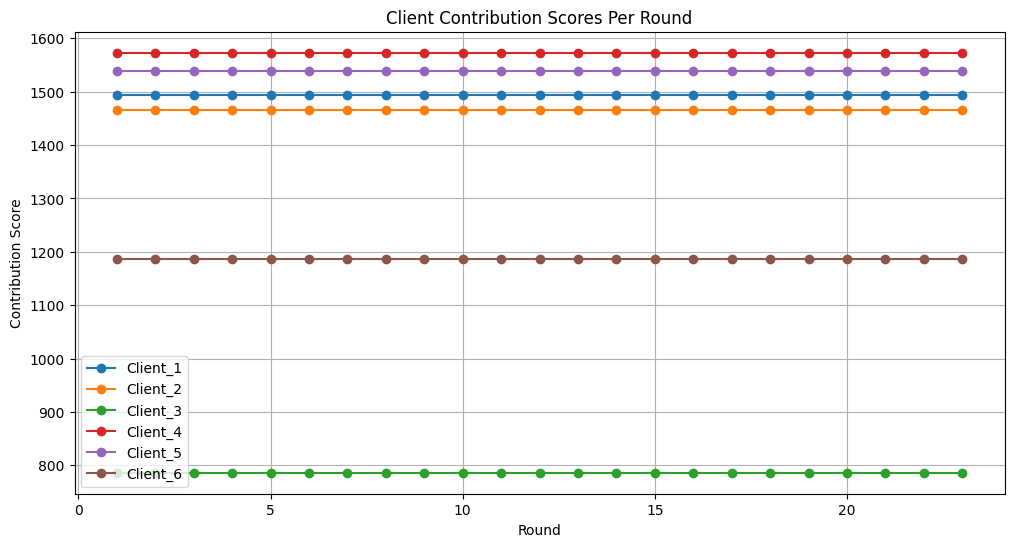

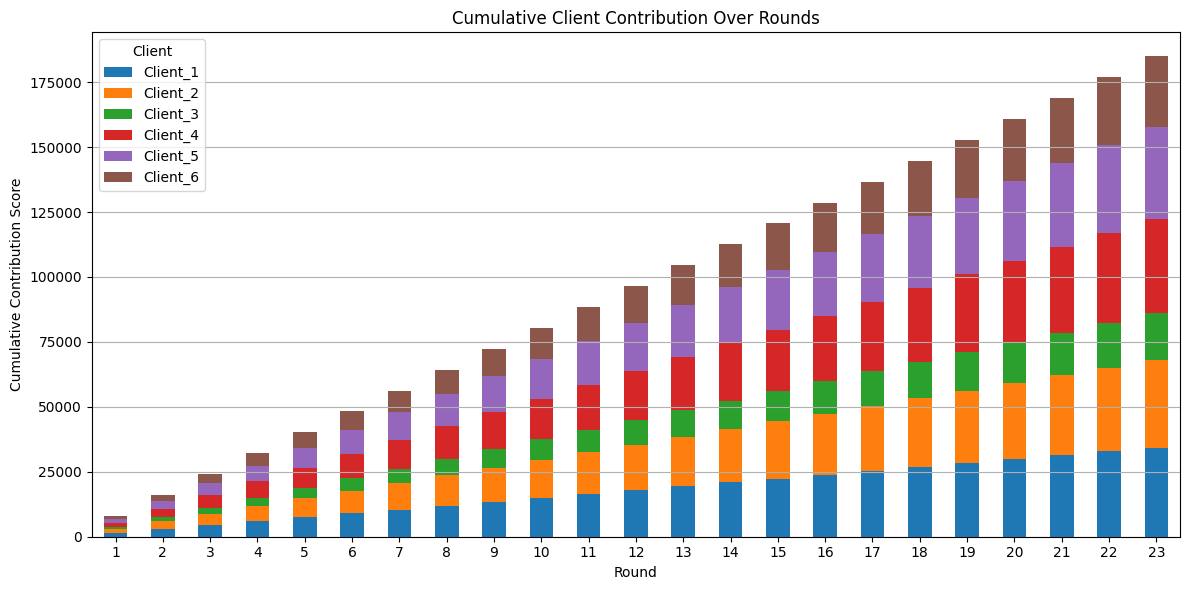

In [ ]:
# --- Plotting Contribution Scores (Line Plot - original) ---

import matplotlib.pyplot as plt
import json
import os
import pandas as pd
import numpy as np # Import numpy for cumulative sum

# Define the directory where contribution scores are saved
contribution_dir = f'/content/drive/MyDrive/FL/contribution/{pass_name}'


# List all contribution files
contribution_files = sorted([f for f in os.listdir(contribution_dir) if f.startswith('contribution_round_') and f.endswith('.json')])

if not contribution_files:
    print(f"No contribution data found in {contribution_dir}")
else:
    # Load contribution data from all rounds
    all_contribution_data = {}
    for filename in contribution_files:
        round_num = int(filename.replace('contribution_round_', '').replace('.json', ''))
        filepath = os.path.join(contribution_dir, filename)
        try:
            with open(filepath, 'r') as f:
                all_contribution_data[round_num] = json.load(f)
        except Exception as e:
            print(f"Error loading contribution data from {filepath}: {e}")

    if all_contribution_data:
        # Convert to a pandas DataFrame for easier plotting
        contribution_df = pd.DataFrame.from_dict(all_contribution_data, orient='index')
        contribution_df.index.name = 'Round'

        # Sort by index (round number)
        contribution_df = contribution_df.sort_index()

        # Calculate cumulative contribution
        cumulative_contribution_df = contribution_df.cumsum(axis=0)

        # --- Plotting Contribution Scores (Line Plot - original) ---
        plt.figure(figsize=(12, 6))
        for client in contribution_df.columns:
            plt.plot(contribution_df.index, contribution_df[client], marker='o', linestyle='-', label=client)

        plt.title('Client Contribution Scores Per Round')
        plt.xlabel('Round')
        plt.ylabel('Contribution Score')
        plt.legend()
        plt.grid(True)
        plt.show()

        # --- Plotting Cumulative Contribution (Stacked Bar Chart) ---
        plt.figure(figsize=(12, 6))
        cumulative_contribution_df.plot(kind='bar', stacked=True, ax=plt.gca()) # Use ax=plt.gca() to plot on the current figure

        plt.title('Cumulative Client Contribution Over Rounds')
        plt.xlabel('Round')
        plt.ylabel('Cumulative Contribution Score')
        plt.xticks(rotation=0) # Keep x-axis labels horizontal
        plt.legend(title='Client')
        plt.grid(axis='y') # Add horizontal grid lines
        plt.tight_layout() # Adjust layout to prevent labels overlapping
        plt.show()


    else:
        print("No valid contribution data loaded.")

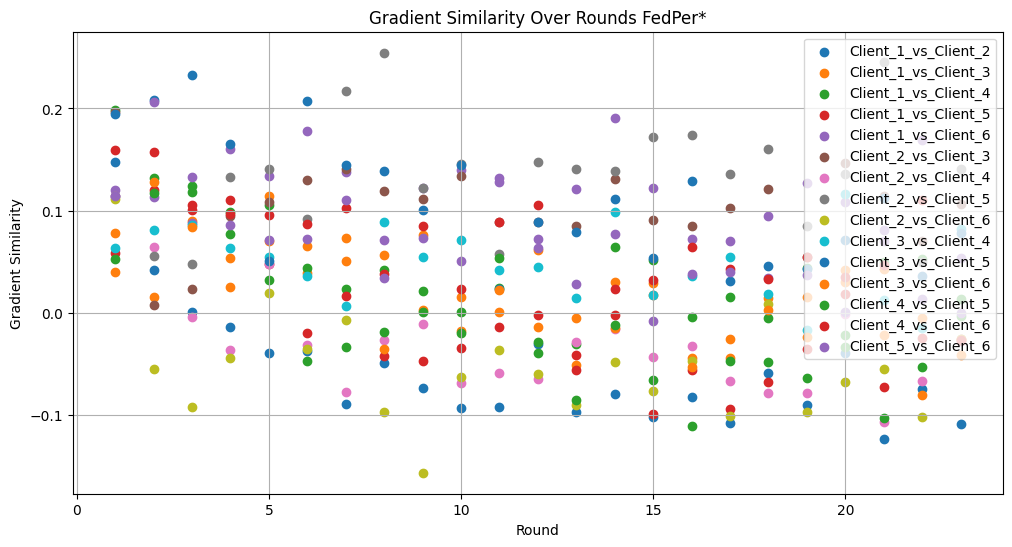

In [ ]:
import os
import json
import matplotlib.pyplot as plt
directory_path = f"/content/drive/MyDrive/FL/gradient_similarity/{pass_name}"
json_files = [f for f in os.listdir(directory_path) if f.endswith('.json')]

gradient_similarity_by_round = {}

for file_name in json_files:
    # Extract round number from file name (e.g., "gradient_similarity_round_1.json")
    try:
        round_number_str = file_name.split('_')[-1].split('.')[0]
        round_number = int(round_number_str)
    except (ValueError, IndexError):
        print(f"Could not extract round number from file name: {file_name}")
        continue

    file_path = os.path.join(directory_path, file_name)
    with open(file_path, 'r') as file:
        data = json.load(file)
        gradient_similarity_by_round[round_number] = data

#display(gradient_similarity_by_round)

rounds = sorted(gradient_similarity_by_round.keys())
client_pairs = list(gradient_similarity_by_round[rounds[0]].keys())

plt.figure(figsize=(12, 6))

for pair in client_pairs:
    similarity_values = [gradient_similarity_by_round[round_num][pair] for round_num in rounds]
    plt.scatter(rounds, similarity_values, label=pair)

plt.xlabel('Round')
plt.ylabel('Gradient Similarity')
plt.title('Gradient Similarity Over Rounds FedPer*')
plt.legend()
plt.grid(True)
plt.show()

## **Store RAM CPU**

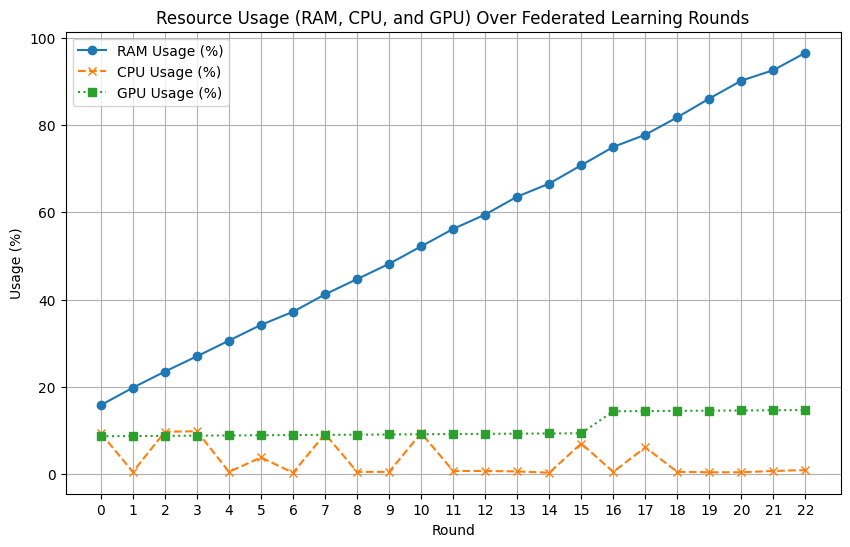

Plotted resource usage history.
/content/drive/MyDrive/FL/resource_history/FL_April_13th/system_usage.csv


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Define the directory where resource history is saved
# Assuming pass_name is defined from previous cells
if 'pass_name' in globals():
    resource_history_dir = f'/content/drive/MyDrive/FL/resource_history/{pass_name}'
    resource_history_path = os.path.join(resource_history_dir, 'system_usage.csv')

    if os.path.exists(resource_history_path):
        try:
            # Load the resource usage history from the CSV file
            resource_history_df = pd.read_csv(resource_history_path)

            # Plotting RAM and CPU usage over rounds
            plt.figure(figsize=(10, 6))

            plt.plot(resource_history_df['Round'], resource_history_df['RAM_Usage(%)'], marker='o', linestyle='-', label='RAM Usage (%)')
            # Check if 'CPU_Usage(%)' column exists before plotting
            if 'CPU_Usage(%)' in resource_history_df.columns:
                 plt.plot(resource_history_df['Round'], resource_history_df['CPU_Usage(%)'], marker='x', linestyle='--', label='CPU Usage (%)')
            # Check if 'GPU_Usage(%)' column exists before plotting and if it has valid data
            if 'GPU_Usage(%)' in resource_history_df.columns and resource_history_df['GPU_Usage(%)'].dropna().empty is False:
                 plt.plot(resource_history_df['Round'], resource_history_df['GPU_Usage(%)'], marker='s', linestyle=':', label='GPU Usage (%)')


            plt.title('Resource Usage (RAM, CPU, and GPU) Over Federated Learning Rounds')
            plt.xlabel('Round')
            plt.ylabel('Usage (%)')
            plt.legend()
            plt.grid(True)
            # Ensure ticks are at each round if the column exists and is numeric
            if 'Round' in resource_history_df.columns and pd.api.types.is_numeric_dtype(resource_history_df['Round']):
                 plt.xticks(resource_history_df['Round'].unique())
            plt.show()

            print("Plotted resource usage history.")

        except Exception as e:
            print(f"Error loading or plotting resource usage history: {e}")
    else:
        print(f"Resource usage history not found at {resource_history_path}.")
else:
    print("Error: pass_name is not defined. Cannot determine the resource history path.")

print(resource_history_path)

In [ ]:
# prompt: screenshot current RAM CPU

import psutil

# Get RAM and CPU usage
ram_usage = psutil.virtual_memory().percent
cpu_usage = psutil.cpu_percent(interval=1) # interval=1 waits for 1 second

print(f"RAM Usage: {ram_usage}%")
print(f"CPU Usage: {cpu_usage}%")

RAM Usage: 94.2%
CPU Usage: 0.5%


## **Đánh giá final global model trên test set**

In [ ]:
# Initialize lists to store global history (moved to global scope)
global_train_loss_history = []
global_train_acc_history = []
global_val_loss_history = []
global_val_acc_history = []
client_train_loss_history = {}
client_train_acc_history = {}

global_history = {
        'train_loss': global_train_loss_history,
        'train_acc': global_train_acc_history,
        'val_loss': global_val_loss_history,
        'val_acc': global_val_acc_history
    }

    # Combine the client histories
client_history = {
        'train_loss': client_train_loss_history,
        'train_acc': client_train_acc_history
    }

In [ ]:
import json
import os

history_path = f"/content/drive/MyDrive/FL/history/{pass_name}/client_history.json"

try:
    with open(history_path, 'r') as f:
        client_history_data = json.load(f)

    # Load train_loss into client_train_loss_history
    if 'train_loss' in client_history_data:
        client_train_loss_history = client_history_data['train_loss']
        print(f"Loaded train_loss history from {history_path}")
    else:
        print(f"Warning: 'train_loss' not found in {history_path}")
        client_train_loss_history = {} # Initialize as empty dict if not found

    # Load train_acc into client_train_acc_history
    if 'train_acc' in client_history_data:
        client_train_acc_history = client_history_data['train_acc']
        print(f"Loaded train_acc history from {history_path}")
    else:
        print(f"Warning: 'train_acc' not found in {history_path}")
        client_train_acc_history = {} # Initialize as empty dict if not found

except FileNotFoundError:
    print(f"Error: History file not found at {history_path}")
    client_train_loss_history = {}
    client_train_acc_history = {}
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {history_path}")
    client_train_loss_history = {}
    client_train_acc_history = {}
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    client_train_loss_history = {}
    client_train_acc_history = {}

Loaded train_loss history from /content/drive/MyDrive/FL/history/FL_April_13th/client_history.json
Loaded train_acc history from /content/drive/MyDrive/FL/history/FL_April_13th/client_history.json


In [ ]:
import json
import os

history_path_global = f"/content/drive/MyDrive/FL/history/{pass_name}/global_history.json"

try:
    with open(history_path_global, 'r') as f:
        global_history_data = json.load(f)

    if 'train_loss' in global_history_data:
        global_train_loss_history = global_history_data['train_loss']
        print(f"Loaded global train_loss history from {history_path_global}")
    else:
        print(f"Warning: 'train_loss' not found in {history_path_global}")
        global_train_loss_history = []

    if 'train_acc' in global_history_data:
        global_train_acc_history = global_history_data['train_acc']
        print(f"Loaded global train_acc history from {history_path_global}")
    else:
        print(f"Warning: 'train_acc' not found in {history_path_global}")
        global_train_acc_history = []

    if 'val_loss' in global_history_data:
        global_val_loss_history = global_history_data['val_loss']
        print(f"Loaded global val_loss history from {history_path_global}")
    else:
        print(f"Warning: 'val_loss' not found in {history_path_global}")
        global_val_loss_history = []

    if 'val_acc' in global_history_data:
        global_val_acc_history = global_history_data['val_acc']
        print(f"Loaded global val_acc history from {history_path_global}")
    else:
        print(f"Warning: 'val_acc' not found in {history_path_global}")
        global_val_acc_history = []

except FileNotFoundError:
    print(f"Error: Global history file not found at {history_path_global}")
    global_train_loss_history = []
    global_train_acc_history = []
    global_val_loss_history = []
    global_val_acc_history = []
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {history_path_global}")
    global_train_loss_history = []
    global_train_acc_history = []
    global_val_loss_history = []
    global_val_acc_history = []
except Exception as e:
    print(f"An unexpected error occurred while loading global history: {e}")
    global_train_loss_history = []
    global_train_acc_history = []
    global_val_loss_history = []
    global_val_acc_history = []


Loaded global train_loss history from /content/drive/MyDrive/FL/history/FL_April_13th/global_history.json
Loaded global train_acc history from /content/drive/MyDrive/FL/history/FL_April_13th/global_history.json
Loaded global val_loss history from /content/drive/MyDrive/FL/history/FL_April_13th/global_history.json
Loaded global val_acc history from /content/drive/MyDrive/FL/history/FL_April_13th/global_history.json


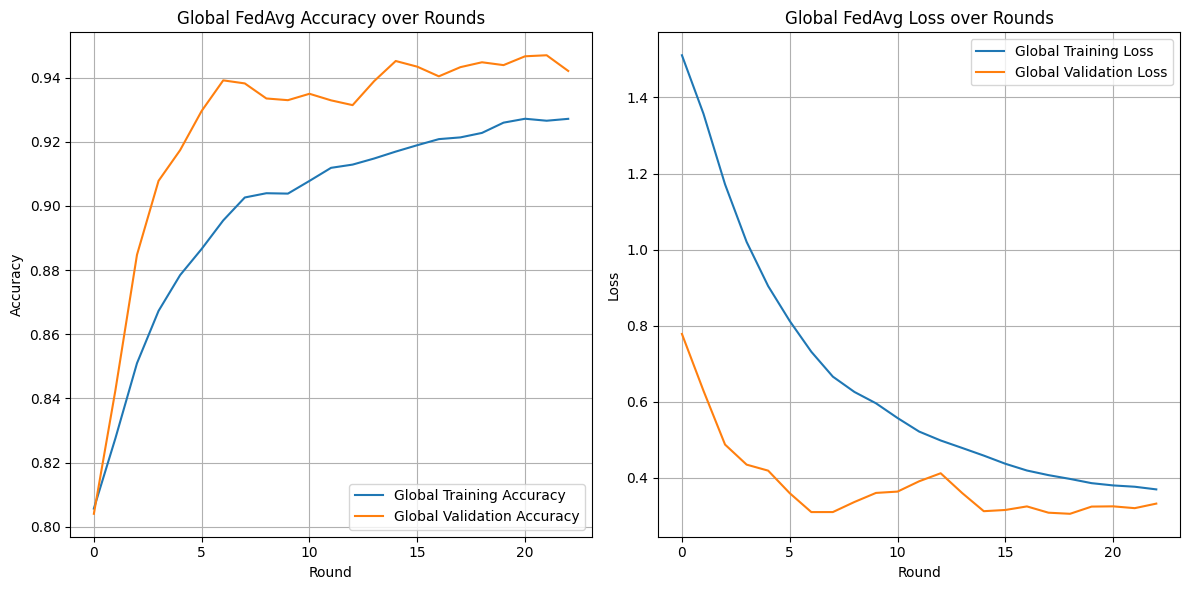

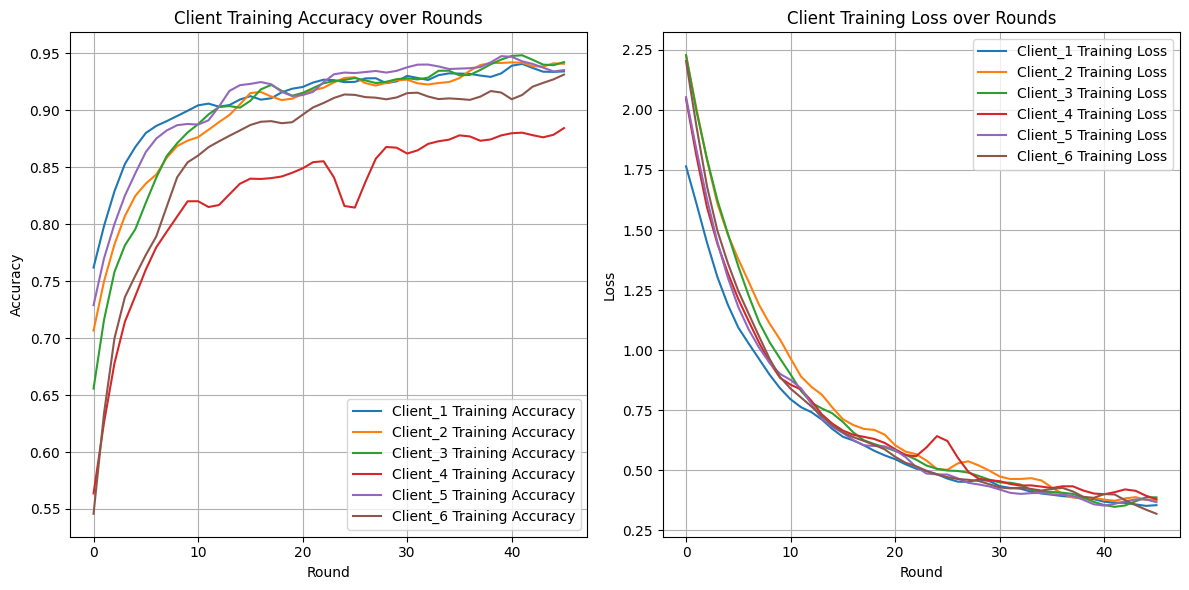

In [ ]:
# Code đạt
#Global  gaussian_filter1d plot FedAvg Model

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Apply Gaussian smoothing to the global accuracy history
smoothed_global_train_acc = gaussian_filter1d(global_train_acc_history, sigma=1)
smoothed_global_val_acc = gaussian_filter1d(global_val_acc_history, sigma=1)
smoothed_global_train_loss = gaussian_filter1d(global_train_loss_history, sigma=1)
smoothed_global_val_loss = gaussian_filter1d(global_val_loss_history, sigma=1)


# Plotting Global FedAvg Accuracy and Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(smoothed_global_train_acc, label='Global Training Accuracy')
plt.plot(smoothed_global_val_acc, label='Global Validation Accuracy')
plt.title('Global FedAvg Accuracy over Rounds')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(smoothed_global_train_loss, label='Global Training Loss')
plt.plot(smoothed_global_val_loss, label='Global Validation Loss')
plt.title('Global FedAvg Loss over Rounds')
plt.xlabel('Round')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plotting Individual Client Training Accuracy over Rounds
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for client, acc_history in client_train_acc_history.items():
    # Apply Gaussian smoothing to client history as well if desired
    smoothed_client_acc = gaussian_filter1d(acc_history, sigma=1) # Smaller sigma for client history
    plt.plot(smoothed_client_acc, label=f'{client} Training Accuracy')
plt.title('Client Training Accuracy over Rounds')
plt.xlabel('Round')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# Plotting Individual Client Training Loss over Rounds
plt.subplot(1, 2, 2)
for client, loss_history in client_train_loss_history.items():
    # Apply Gaussian smoothing to client history as well if desired
    smoothed_client_loss = gaussian_filter1d(loss_history, sigma=1) # Smaller sigma for client history
    plt.plot(smoothed_client_loss, label=f'{client} Training Loss')
plt.title('Client Training Loss over Rounds')
plt.xlabel('Round')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


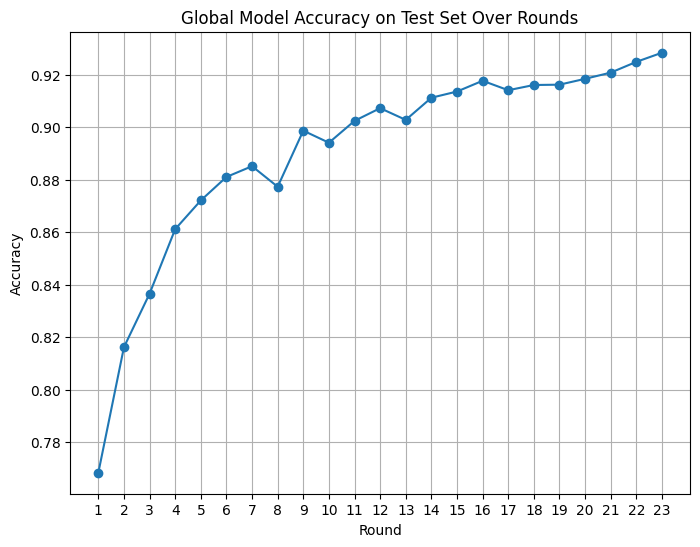

In [ ]:
import matplotlib.pyplot as plt

# Assuming global_train_acc_history is populated from the training rounds

if 'global_train_acc_history' in globals() and global_train_acc_history:
    plt.figure(figsize=(8, 6))
    plt.plot(global_train_acc_history, marker='o', linestyle='-')
    plt.title('Global Model Accuracy on Test Set Over Rounds')
    plt.xlabel('Round')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(range(len(global_train_acc_history)), range(1, len(global_train_acc_history) + 1)) # Label x-axis with round numbers
    plt.show()
else:
    print("Global training accuracy history not found or is empty.")

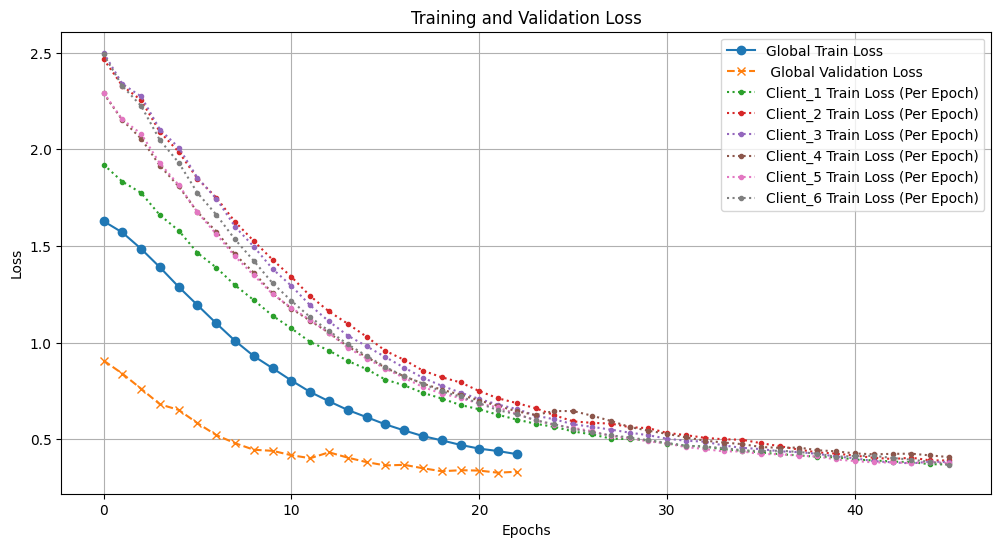

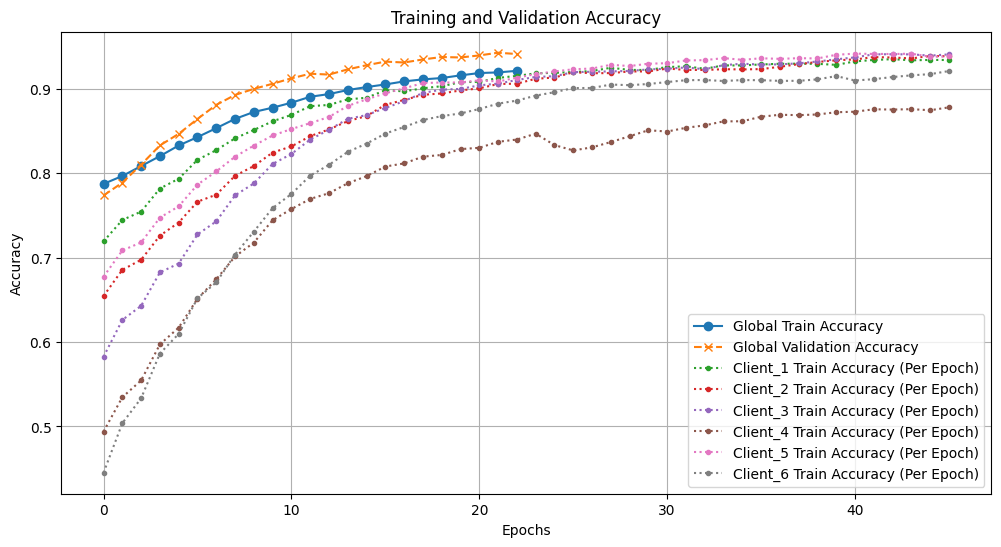

In [ ]:
# prompt: Smooth the  client Training and Validation Accuracy plot

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import numpy as np # Import numpy

def smooth_curve(points, factor=0.8):
  """Smoothes a curve with a moving average."""
  smoothed_points = []
  for point in points:
    if smoothed_points:
      previous = smoothed_points[-1]
      smoothed_points.append(previous * factor + point * (1 - factor))
    else:
      smoothed_points.append(point)
  return smoothed_points

# Define the indices for plotting
# The global history includes initial global epochs + federated rounds
# The error occurs here because global_train_loss_history and global_val_loss_history
# are only populated during the FL rounds, not the initial global epochs.
# Adjusting the indices to match the actual data points available.

# Indices for global history (which is only populated during FL rounds)
global_indices = np.arange(len(global_train_loss_history))


# Plotting Loss
plt.figure(figsize=(12, 6))
# Plot global history using the corrected indices
plt.plot(global_indices, smooth_curve(global_train_loss_history), label='Global Train Loss', marker='o', linestyle='-')
if global_val_loss_history:
    # Indices for global validation history (which is only populated during FL rounds)
    global_val_indices = np.arange(len(global_val_loss_history))
    plt.plot(global_val_indices, smooth_curve(global_val_loss_history), label=' Global Validation Loss', marker='x', linestyle='--')


for client, history in client_train_loss_history.items():
    if history:
        # Client history is recorded per epoch within each round.
        # We need to create indices that reflect the total number of local epochs across rounds.
        # Assuming each client trains for `epochs_local` epochs per round.
        total_client_epochs = len(history)
        client_indices = np.arange(total_client_epochs)
        plt.plot(client_indices, smooth_curve(history), label=f'{client} Train Loss (Per Epoch)', marker='.', linestyle=':')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs') # Changed label to reflect per-epoch plotting for clients
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Plotting Accuracy
plt.figure(figsize=(12, 6))
# Plot global history using the corrected indices
plt.plot(global_indices, smooth_curve(global_train_acc_history), label='Global Train Accuracy', marker='o', linestyle='-')
if global_val_acc_history:
    # Indices for global validation history (which is only populated during FL rounds)
    global_val_indices = np.arange(len(global_val_acc_history))
    plt.plot(global_val_indices, smooth_curve(global_val_acc_history), label='Global Validation Accuracy', marker='x', linestyle='--')


for client, history in client_train_acc_history.items():
     if history:
        # Client history is recorded per epoch within each round.
        # We need to create indices that reflect the total number of local epochs across rounds.
        total_client_epochs = len(history)
        client_indices = np.arange(total_client_epochs)
        plt.plot(client_indices, smooth_curve(history), label=f'{client} Train Accuracy (Per Epoch)', marker='.', linestyle=':')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs') # Changed label to reflect per-epoch plotting for clients
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## ĐÁnh Giá

Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_23/global_model_round_23.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_23/global_model_round_23.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1076s 22s/step - accuracy: 0.8949 - loss: 0.4735
Test Loss: 47.35443890094757
Test Accuracy: 89.49366807937622
50/50 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        86.20   92.23     89.11   386.00
Leaf_Blast        83.33   83.99     83.66   381.00
Leaf_Blight       94.23   89.09     91.59   385.00
Normal            94.27   92.29     93.27   428.00
accuracy          89.49   89.49     89.49     0.89
macro avg         89.51   89.40     89.41  1580.00
weighted avg      89.65   89.49     8

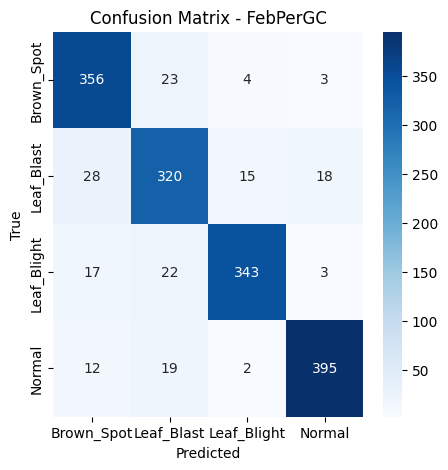

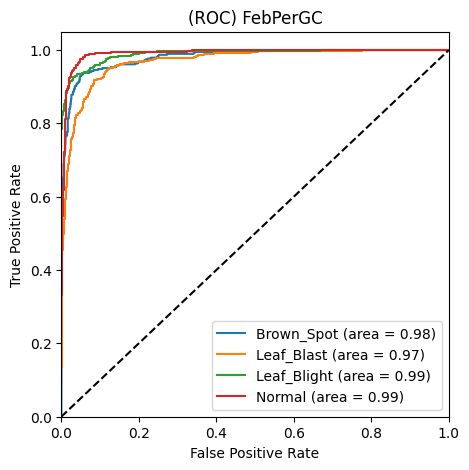

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step
Total prediction time for 1580 images: 123.68 seconds
Execution time per image: 0.0783 seconds


,precision,recall,f1-score,support
Brown_Spot,86.20,92.23,89.11,386.00
Leaf_Blast,83.33,83.99,83.66,381.00
Leaf_Blight,94.23,89.09,91.59,385.00
Normal,94.27,92.29,93.27,428.00
accuracy,89.49,89.49,89.49,0.89
macro avg,89.51,89.40,89.41,1580.00
weighted avg,89.65,89.49,89.53,1580.00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
# --- Re-initialize fl_model with the original unquantized version ---
# Load the original unquantized model from the best model path
#model_dir = f'/content/drive/MyDrive/FL/model/{pass_name}'
#best_model_path = os.path.join(model_dir, "FL_final_global_model.keras")
title="FebPerGC"
# 32 - 89.05
round = 23
best_model_path = f"/content/drive/MyDrive/FL/model/{pass_name}/round_{round}/global_model_round_{round}.keras"
#best_model_path = f"/content/drive/MyDrive/FL/local_models/FL_April_11th/Client_6_model.keras"
print("Test by model:", best_model_path)
if os.path.exists(best_model_path):
    try:
        print(f"Loading original initial global model from {best_model_path}...")
        fl_model = tf.keras.models.load_model(
            best_model_path,
            custom_objects=custom_objects
        )
        print("Original model loaded successfully for FL rounds.")

    except Exception as e:
        print(f"Error loading the original model for FL rounds: {e}")
        fl_model = None # Ensure fl_model is None if loading fails

else:
    print(f"Error: best_model_path does not exist at {best_model_path}. Cannot load the original model for FL rounds.")
    fl_model = None # Ensure fl_model is None if path is invalid

# Ensure fl_model is compiled before starting FL rounds
if fl_model:
     print("Compiling initial global model for FL rounds...")
     fl_model.compile(optimizer='adam',
                                  loss='categorical_crossentropy',
                                  metrics=['accuracy'])
     print("Model compiled for FL rounds.")
else:
    print("Initial global model not loaded successfully. Cannot start FL rounds.")

##=================
test_dir="/content/drive/MyDrive/FL/global/test"
valid_datagen = ImageDataGenerator(rescale=1./255)
test_generator = valid_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
# Đánh giá mô hình
loss, accuracy = fl_model.evaluate(test_generator)
print("Test Loss:", loss*100)
print("Test Accuracy:", accuracy*100)

# Dự đoán
y_pred = fl_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Lấy tên lớp
global_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
class_names = global_classes
num_classes = len(class_names)
# Classification report dưới dạng phần trăm
report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df[['precision', 'recall', 'f1-score']] *= 100  # Nhân hệ số 10 để chuyển sang phần trăm

# Làm tròn và in kết quả
print("\nClassification Report (in %):")
print(report_df.round(2))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ' + title)
plt.show()

y_true_binarized = label_binarize(y_true, classes=np.arange(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(5, 5))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) '+title)
plt.legend(loc="lower right")
plt.show()



# Load the final global model
"""try:
    # Assuming custom_objects are defined in a previous cell
    loaded_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    print(f"Model loaded successfully from {model_path}")
except Exception as e:
    print(f"Error loading model from {model_path}: {e}")
    loaded_model = None"""

if fl_model:
    # Get the number of images in the test set
    num_test_images = test_generator.samples
    print(f"Number of test images: {num_test_images}")

    # Measure the prediction time
    start_time = time.time()
    fl_model.predict(test_generator)
    end_time = time.time()

    total_prediction_time = end_time - start_time
    print(f"Total prediction time for {num_test_images} images: {total_prediction_time:.2f} seconds")

    # Calculate execution time per image
    if num_test_images > 0:
        execution_time_per_image = total_prediction_time / num_test_images
        print(f"Execution time per image: {execution_time_per_image:.4f} seconds")
    else:
        print("No test images found to calculate execution time per image.")
else:
    print("Could not load the model. Cannot calculate execution time.")


display(report_df.round(2))

Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_22/global_model_round_22.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_22/global_model_round_22.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 512s 10s/step - accuracy: 0.8949 - loss: 0.4785
Test Loss: 47.84838259220123
Test Accuracy: 89.49366807937622
50/50 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        92.96   82.12     87.21   386.00
Leaf_Blast        81.28   86.61     83.86   381.00
Leaf_Blight       89.43   94.55     91.92   385.00
Normal            94.60   94.16     94.38   428.00
accuracy          89.49   89.49     89.49     0.89
macro avg         89.57   89.36     89.34  1580.00
weighted avg      89.73   89.49     89

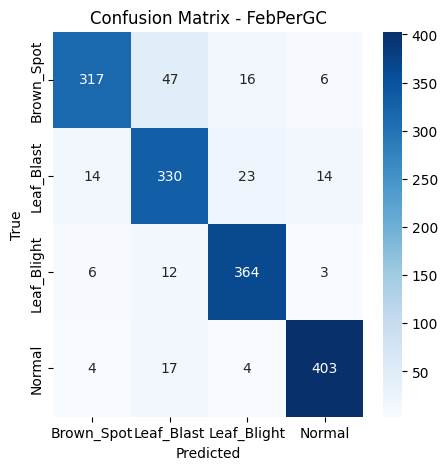

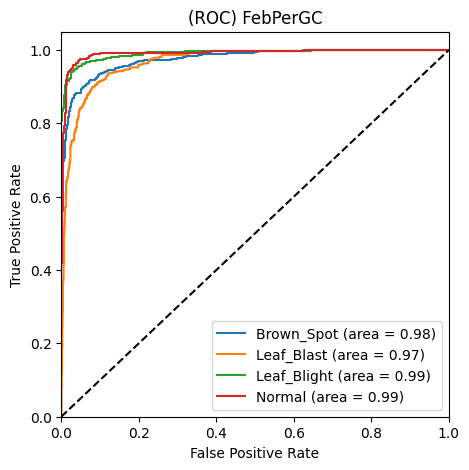

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step
Total prediction time for 1580 images: 114.04 seconds
Execution time per image: 0.0722 seconds


,precision,recall,f1-score,support
Brown_Spot,92.96,82.12,87.21,386.00
Leaf_Blast,81.28,86.61,83.86,381.00
Leaf_Blight,89.43,94.55,91.92,385.00
Normal,94.60,94.16,94.38,428.00
accuracy,89.49,89.49,89.49,0.89
macro avg,89.57,89.36,89.34,1580.00
weighted avg,89.73,89.49,89.49,1580.00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
# --- Re-initialize fl_model with the original unquantized version ---
# Load the original unquantized model from the best model path
#model_dir = f'/content/drive/MyDrive/FL/model/{pass_name}'
#best_model_path = os.path.join(model_dir, "FL_final_global_model.keras")
title="FebPerGC"
# 32 - 89.05
round = 22
best_model_path = f"/content/drive/MyDrive/FL/model/{pass_name}/round_{round}/global_model_round_{round}.keras"
#best_model_path = f"/content/drive/MyDrive/FL/local_models/FL_April_11th/Client_6_model.keras"
print("Test by model:", best_model_path)
if os.path.exists(best_model_path):
    try:
        print(f"Loading original initial global model from {best_model_path}...")
        fl_model = tf.keras.models.load_model(
            best_model_path,
            custom_objects=custom_objects
        )
        print("Original model loaded successfully for FL rounds.")

    except Exception as e:
        print(f"Error loading the original model for FL rounds: {e}")
        fl_model = None # Ensure fl_model is None if loading fails

else:
    print(f"Error: best_model_path does not exist at {best_model_path}. Cannot load the original model for FL rounds.")
    fl_model = None # Ensure fl_model is None if path is invalid

# Ensure fl_model is compiled before starting FL rounds
if fl_model:
     print("Compiling initial global model for FL rounds...")
     fl_model.compile(optimizer='adam',
                                  loss='categorical_crossentropy',
                                  metrics=['accuracy'])
     print("Model compiled for FL rounds.")
else:
    print("Initial global model not loaded successfully. Cannot start FL rounds.")

##=================
test_dir="/content/drive/MyDrive/FL/global/test"
valid_datagen = ImageDataGenerator(rescale=1./255)
test_generator = valid_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
# Đánh giá mô hình
loss, accuracy = fl_model.evaluate(test_generator)
print("Test Loss:", loss*100)
print("Test Accuracy:", accuracy*100)

# Dự đoán
y_pred = fl_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Lấy tên lớp
global_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
class_names = global_classes
num_classes = len(class_names)
# Classification report dưới dạng phần trăm
report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df[['precision', 'recall', 'f1-score']] *= 100  # Nhân hệ số 10 để chuyển sang phần trăm

# Làm tròn và in kết quả
print("\nClassification Report (in %):")
print(report_df.round(2))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ' + title)
plt.show()

y_true_binarized = label_binarize(y_true, classes=np.arange(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(5, 5))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) '+title)
plt.legend(loc="lower right")
plt.show()



# Load the final global model
"""try:
    # Assuming custom_objects are defined in a previous cell
    loaded_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    print(f"Model loaded successfully from {model_path}")
except Exception as e:
    print(f"Error loading model from {model_path}: {e}")
    loaded_model = None"""

if fl_model:
    # Get the number of images in the test set
    num_test_images = test_generator.samples
    print(f"Number of test images: {num_test_images}")

    # Measure the prediction time
    start_time = time.time()
    fl_model.predict(test_generator)
    end_time = time.time()

    total_prediction_time = end_time - start_time
    print(f"Total prediction time for {num_test_images} images: {total_prediction_time:.2f} seconds")

    # Calculate execution time per image
    if num_test_images > 0:
        execution_time_per_image = total_prediction_time / num_test_images
        print(f"Execution time per image: {execution_time_per_image:.4f} seconds")
    else:
        print("No test images found to calculate execution time per image.")
else:
    print("Could not load the model. Cannot calculate execution time.")


display(report_df.round(2))

Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_15/global_model_round_15.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_15/global_model_round_15.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8968 - loss: 0.4034
Test Loss: 40.33716022968292
Test Accuracy: 89.6835446357727
50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        90.03   86.53     88.24    386.0
Leaf_Blast        82.53   85.56     84.02    381.0
Leaf_Blight       91.84   90.65     91.24    385.0
Normal            94.01   95.33     94.66    428.0
accuracy          89.68   89.68     89.68      0.9
macro avg         89.60   89.52     89.54   1580.0
weighted avg      89.74   89.68     89.6

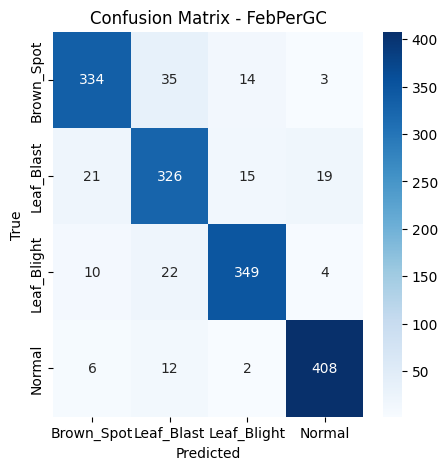

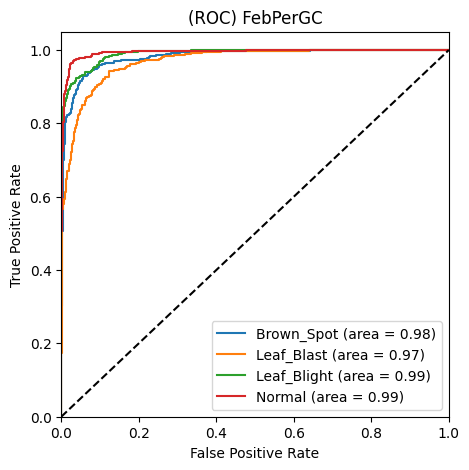

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step
Total prediction time for 1580 images: 103.33 seconds
Execution time per image: 0.0654 seconds


,precision,recall,f1-score,support
Brown_Spot,90.03,86.53,88.24,386.0
Leaf_Blast,82.53,85.56,84.02,381.0
Leaf_Blight,91.84,90.65,91.24,385.0
Normal,94.01,95.33,94.66,428.0
accuracy,89.68,89.68,89.68,0.9
macro avg,89.60,89.52,89.54,1580.0
weighted avg,89.74,89.68,89.69,1580.0


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_16/global_model_round_16.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_16/global_model_round_16.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.8994 - loss: 0.3894
Test Loss: 38.94272744655609
Test Accuracy: 89.9367094039917
50/50 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        88.95   89.64     89.29    386.0
Leaf_Blast        82.19   84.78     83.46    381.0
Leaf_Blight       97.41   88.05     92.50    385.0
Normal            91.78   96.50     94.08    428.0
accuracy          89.94   89.94     89.94      0.9
macro avg         90.08   89.74     89.83   1580.0
weighted avg      90.15   89.94     89.9

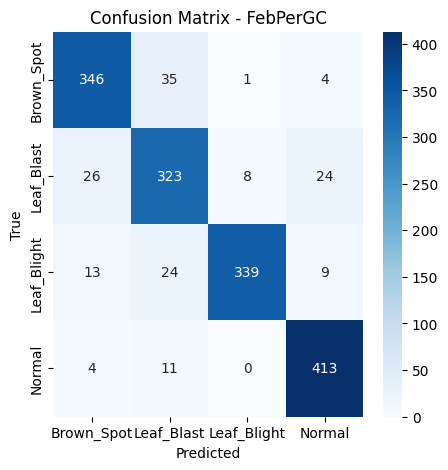

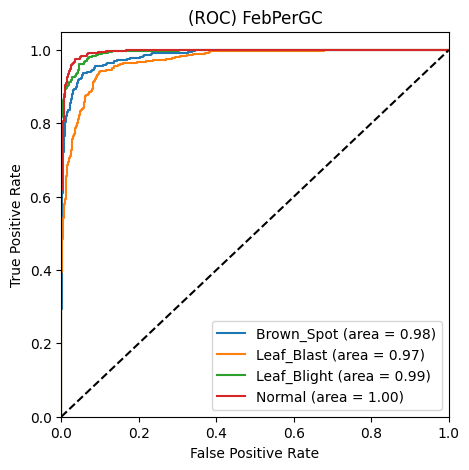

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step
Total prediction time for 1580 images: 146.27 seconds
Execution time per image: 0.0926 seconds


,precision,recall,f1-score,support
Brown_Spot,88.95,89.64,89.29,386.0
Leaf_Blast,82.19,84.78,83.46,381.0
Leaf_Blight,97.41,88.05,92.50,385.0
Normal,91.78,96.50,94.08,428.0
accuracy,89.94,89.94,89.94,0.9
macro avg,90.08,89.74,89.83,1580.0
weighted avg,90.15,89.94,89.96,1580.0


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_17/global_model_round_17.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_17/global_model_round_17.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8880 - loss: 0.4284
Test Loss: 42.84220635890961
Test Accuracy: 88.79746794700623
50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        78.63   95.34     86.18   386.00
Leaf_Blast        91.00   74.28     81.79   381.00
Leaf_Blight       94.97   88.31     91.52   385.00
Normal            93.00   96.26     94.60   428.00
accuracy          88.80   88.80     88.80     0.89
macro avg         89.40   88.55     88.52  1580.00
weighted avg      89.49   88.80     88.

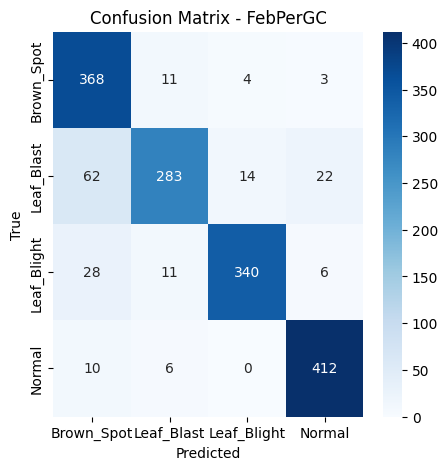

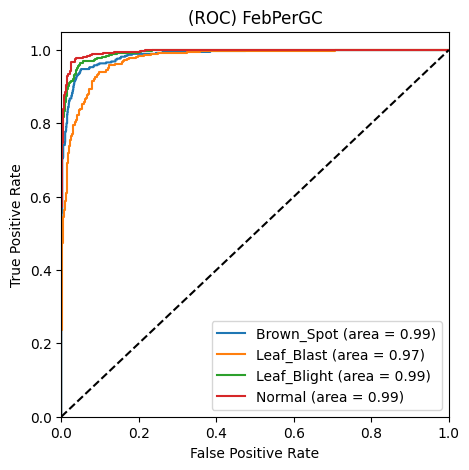

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step
Total prediction time for 1580 images: 100.91 seconds
Execution time per image: 0.0639 seconds


,precision,recall,f1-score,support
Brown_Spot,78.63,95.34,86.18,386.00
Leaf_Blast,91.00,74.28,81.79,381.00
Leaf_Blight,94.97,88.31,91.52,385.00
Normal,93.00,96.26,94.60,428.00
accuracy,88.80,88.80,88.80,0.89
macro avg,89.40,88.55,88.52,1580.00
weighted avg,89.49,88.80,88.71,1580.00


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_18/global_model_round_18.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_18/global_model_round_18.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8975 - loss: 0.4228
Test Loss: 42.282408475875854
Test Accuracy: 89.74683284759521
50/50 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        90.32   87.05     88.65    386.0
Leaf_Blast        86.34   82.94     84.61    381.0
Leaf_Blight       88.66   91.43     90.03    385.0
Normal            93.03   96.73     94.85    428.0
accuracy          89.75   89.75     89.75      0.9
macro avg         89.59   89.54     89.53   1580.0
weighted avg      89.69   89.75     89

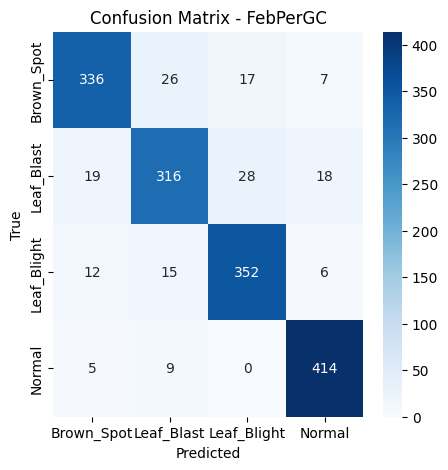

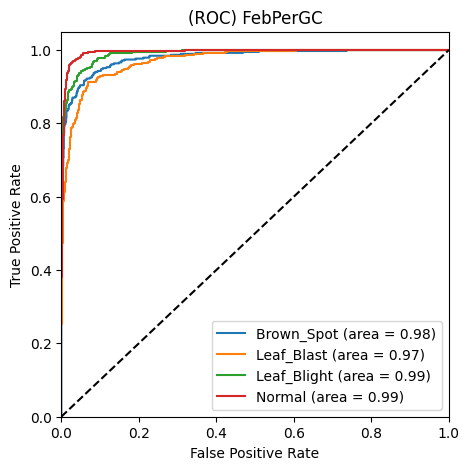

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step
Total prediction time for 1580 images: 104.79 seconds
Execution time per image: 0.0663 seconds


,precision,recall,f1-score,support
Brown_Spot,90.32,87.05,88.65,386.0
Leaf_Blast,86.34,82.94,84.61,381.0
Leaf_Blight,88.66,91.43,90.03,385.0
Normal,93.03,96.73,94.85,428.0
accuracy,89.75,89.75,89.75,0.9
macro avg,89.59,89.54,89.53,1580.0
weighted avg,89.69,89.75,89.69,1580.0


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_19/global_model_round_19.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_19/global_model_round_19.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.8975 - loss: 0.4050
Test Loss: 40.495604276657104
Test Accuracy: 89.74683284759521
50/50 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        88.46   89.38     88.92    386.0
Leaf_Blast        84.53   83.20     83.86    381.0
Leaf_Blight       92.08   90.65     91.36    385.0
Normal            93.35   95.09     94.21    428.0
accuracy          89.75   89.75     89.75      0.9
macro avg         89.61   89.58     89.59   1580.0
weighted avg      89.72   89.75     89

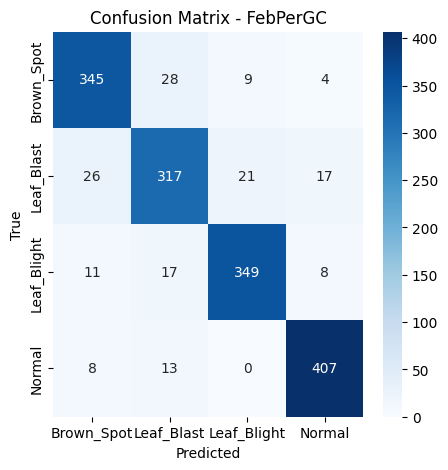

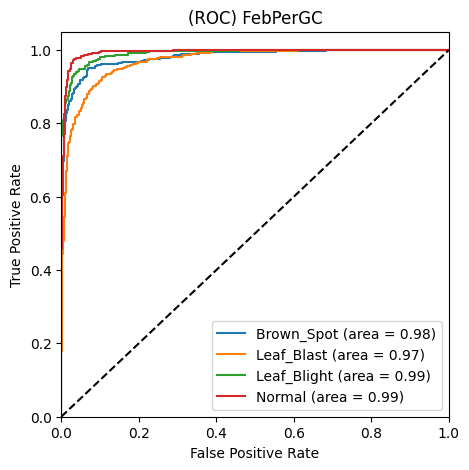

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step
Total prediction time for 1580 images: 102.54 seconds
Execution time per image: 0.0649 seconds


,precision,recall,f1-score,support
Brown_Spot,88.46,89.38,88.92,386.0
Leaf_Blast,84.53,83.20,83.86,381.0
Leaf_Blight,92.08,90.65,91.36,385.0
Normal,93.35,95.09,94.21,428.0
accuracy,89.75,89.75,89.75,0.9
macro avg,89.61,89.58,89.59,1580.0
weighted avg,89.72,89.75,89.73,1580.0


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_20/global_model_round_20.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_20/global_model_round_20.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.8968 - loss: 0.4181
Test Loss: 41.80728495121002
Test Accuracy: 89.6835446357727
50/50 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        83.37   94.82     88.73    386.0
Leaf_Blast        87.28   79.27     83.08    381.0
Leaf_Blight       94.04   90.13     92.04    385.0
Normal            94.37   93.93     94.15    428.0
accuracy          89.68   89.68     89.68      0.9
macro avg         89.76   89.53     89.50   1580.0
weighted avg      89.89   89.68     89.6

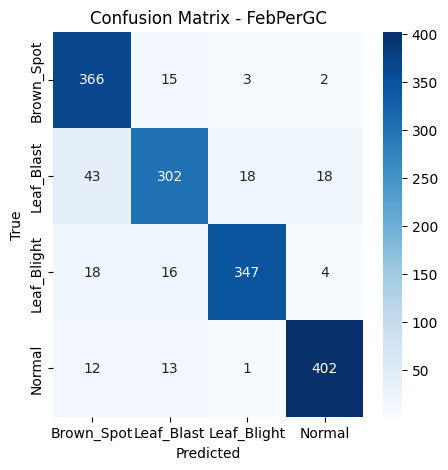

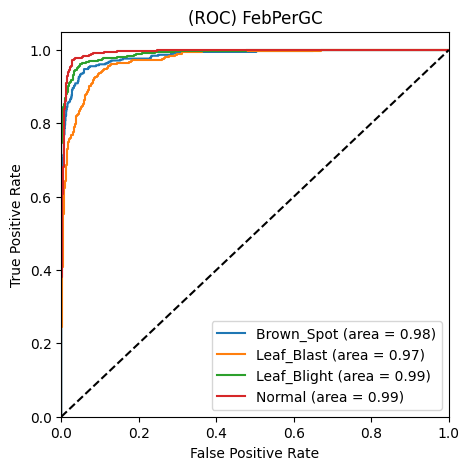

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step
Total prediction time for 1580 images: 101.65 seconds
Execution time per image: 0.0643 seconds


,precision,recall,f1-score,support
Brown_Spot,83.37,94.82,88.73,386.0
Leaf_Blast,87.28,79.27,83.08,381.0
Leaf_Blight,94.04,90.13,92.04,385.0
Normal,94.37,93.93,94.15,428.0
accuracy,89.68,89.68,89.68,0.9
macro avg,89.76,89.53,89.50,1580.0
weighted avg,89.89,89.68,89.64,1580.0


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_21/global_model_round_21.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_21/global_model_round_21.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.8968 - loss: 0.4378
Test Loss: 43.77574026584625
Test Accuracy: 89.6835446357727
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        89.58   89.12     89.35    386.0
Leaf_Blast        84.76   83.20     83.97    381.0
Leaf_Blight       90.75   91.69     91.21    385.0
Normal            93.07   94.16     93.61    428.0
accuracy          89.68   89.68     89.68      0.9
macro avg         89.54   89.54     89.54   1580.0
weighted avg      89.65   89.68     89.6

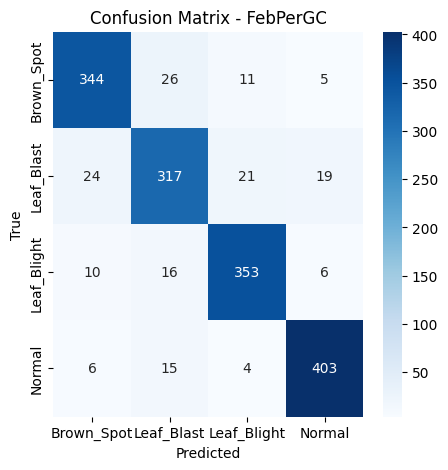

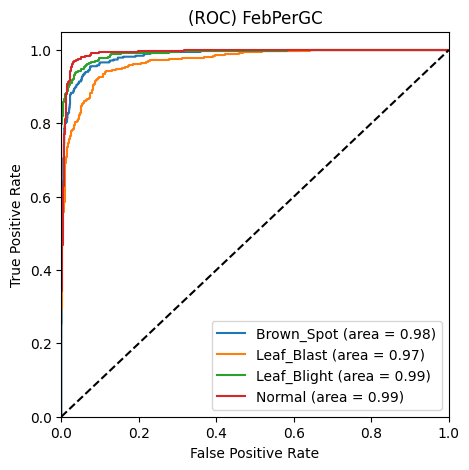

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step
Total prediction time for 1580 images: 108.58 seconds
Execution time per image: 0.0687 seconds


,precision,recall,f1-score,support
Brown_Spot,89.58,89.12,89.35,386.0
Leaf_Blast,84.76,83.20,83.97,381.0
Leaf_Blight,90.75,91.69,91.21,385.0
Normal,93.07,94.16,93.61,428.0
accuracy,89.68,89.68,89.68,0.9
macro avg,89.54,89.54,89.54,1580.0
weighted avg,89.65,89.68,89.66,1580.0


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_22/global_model_round_22.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_22/global_model_round_22.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8949 - loss: 0.4785
Test Loss: 47.84838259220123
Test Accuracy: 89.49366807937622
50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        92.96   82.12     87.21   386.00
Leaf_Blast        81.28   86.61     83.86   381.00
Leaf_Blight       89.43   94.55     91.92   385.00
Normal            94.60   94.16     94.38   428.00
accuracy          89.49   89.49     89.49     0.89
macro avg         89.57   89.36     89.34  1580.00
weighted avg      89.73   89.49     89.

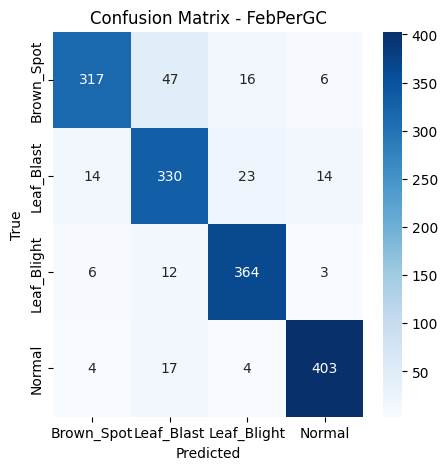

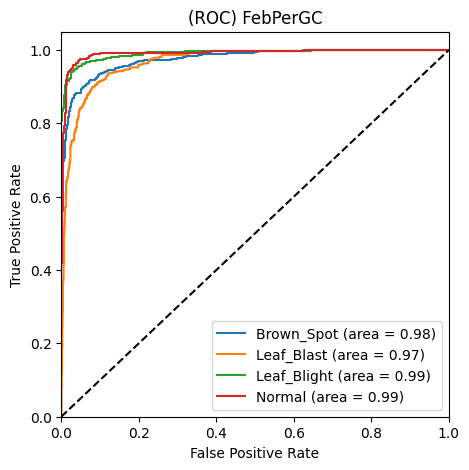

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step
Total prediction time for 1580 images: 102.57 seconds
Execution time per image: 0.0649 seconds


,precision,recall,f1-score,support
Brown_Spot,92.96,82.12,87.21,386.00
Leaf_Blast,81.28,86.61,83.86,381.00
Leaf_Blight,89.43,94.55,91.92,385.00
Normal,94.60,94.16,94.38,428.00
accuracy,89.49,89.49,89.49,0.89
macro avg,89.57,89.36,89.34,1580.00
weighted avg,89.73,89.49,89.49,1580.00


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_23/global_model_round_23.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_23/global_model_round_23.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Found 1580 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.8949 - loss: 0.4735
Test Loss: 47.35443890094757
Test Accuracy: 89.49366807937622
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        86.20   92.23     89.11   386.00
Leaf_Blast        83.33   83.99     83.66   381.00
Leaf_Blight       94.23   89.09     91.59   385.00
Normal            94.27   92.29     93.27   428.00
accuracy          89.49   89.49     89.49     0.89
macro avg         89.51   89.40     89.41  1580.00
weighted avg      89.65   89.49     89.

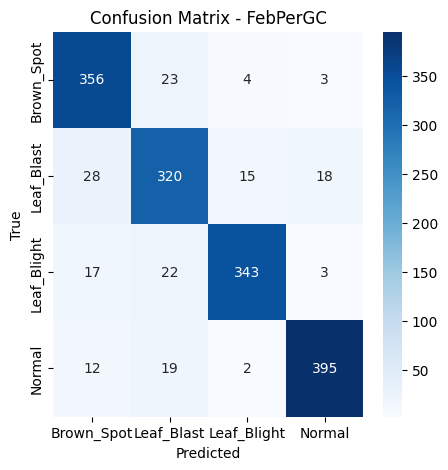

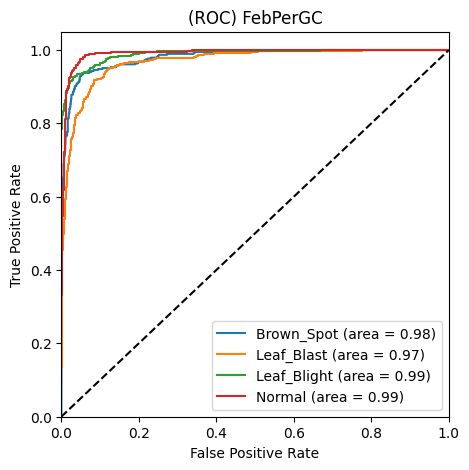

Number of test images: 1580
50/50 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step
Total prediction time for 1580 images: 146.05 seconds
Execution time per image: 0.0924 seconds


,precision,recall,f1-score,support
Brown_Spot,86.20,92.23,89.11,386.00
Leaf_Blast,83.33,83.99,83.66,381.00
Leaf_Blight,94.23,89.09,91.59,385.00
Normal,94.27,92.29,93.27,428.00
accuracy,89.49,89.49,89.49,0.89
macro avg,89.51,89.40,89.41,1580.00
weighted avg,89.65,89.49,89.53,1580.00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
# --- Re-initialize fl_model with the original unquantized version ---
# Load the original unquantized model from the best model path
#model_dir = f'/content/drive/MyDrive/FL/model/{pass_name}'
#best_model_path = os.path.join(model_dir, "FL_final_global_model.keras")
title="FebPerGC"
# 32 - 89.05
#round = 15
for round in range(15,24):
      best_model_path = f"/content/drive/MyDrive/FL/model/{pass_name}/round_{round}/global_model_round_{round}.keras"
      #best_model_path = f"/content/drive/MyDrive/FL/model/FL_Dec_6th/round_27/global_model_round_27.keras"
      print("Test by model:", best_model_path)
      if os.path.exists(best_model_path):
          try:
              print(f"Loading original initial global model from {best_model_path}...")
              fl_model = tf.keras.models.load_model(
                  best_model_path,
                  custom_objects=custom_objects
              )
              print("Original model loaded successfully for FL rounds.")

          except Exception as e:
              print(f"Error loading the original model for FL rounds: {e}")
              fl_model = None # Ensure fl_model is None if loading fails

      else:
          print(f"Error: best_model_path does not exist at {best_model_path}. Cannot load the original model for FL rounds.")
          fl_model = None # Ensure fl_model is None if path is invalid

      # Ensure fl_model is compiled before starting FL rounds
      if fl_model:
          print("Compiling initial global model for FL rounds...")
          fl_model.compile(optimizer='adam',
                                        loss='categorical_crossentropy',
                                        metrics=['accuracy'])
          print("Model compiled for FL rounds.")
      else:
          print("Initial global model not loaded successfully. Cannot start FL rounds.")

      ##=================
      test_dir="/content/drive/MyDrive/FL/global/test"
      valid_datagen = ImageDataGenerator(rescale=1./255)
      test_generator = valid_datagen.flow_from_directory(
          test_dir,
          target_size=(224,224),
          batch_size=32,
          class_mode='categorical',
          shuffle=False
      )
      # Đánh giá mô hình
      loss, accuracy = fl_model.evaluate(test_generator)
      print("Test Loss:", loss*100)
      print("Test Accuracy:", accuracy*100)

      # Dự đoán
      y_pred = fl_model.predict(test_generator)
      y_pred_classes = np.argmax(y_pred, axis=1)
      y_true = test_generator.classes

      # Lấy tên lớp
      global_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
      class_names = global_classes
      num_classes = len(class_names)
      # Classification report dưới dạng phần trăm
      report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
      report_df = pd.DataFrame(report).transpose()
      report_df[['precision', 'recall', 'f1-score']] *= 100  # Nhân hệ số 10 để chuyển sang phần trăm

      # Làm tròn và in kết quả
      print("\nClassification Report (in %):")
      print(report_df.round(2))

      # Confusion matrix
      cm = confusion_matrix(y_true, y_pred_classes)
      plt.figure(figsize=(5, 5))
      sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
      plt.xlabel('Predicted')
      plt.ylabel('True')
      plt.title('Confusion Matrix - ' + title)
      plt.show()

      y_true_binarized = label_binarize(y_true, classes=np.arange(num_classes))

      fpr = dict()
      tpr = dict()
      roc_auc = dict()
      for i in range(num_classes):
          fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred[:, i])
          roc_auc[i] = auc(fpr[i], tpr[i])

      plt.figure(figsize=(5, 5))
      for i in range(num_classes):
          plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (area = {roc_auc[i]:.2f})')

      plt.plot([0, 1], [0, 1], 'k--')
      plt.xlim([0.0, 1.0])
      plt.ylim([0.0, 1.05])
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title('(ROC) '+title)
      plt.legend(loc="lower right")
      plt.show()



      # Load the final global model
      """try:
          # Assuming custom_objects are defined in a previous cell
          loaded_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
          print(f"Model loaded successfully from {model_path}")
      except Exception as e:
          print(f"Error loading model from {model_path}: {e}")
          loaded_model = None"""

      if fl_model:
          # Get the number of images in the test set
          num_test_images = test_generator.samples
          print(f"Number of test images: {num_test_images}")

          # Measure the prediction time
          start_time = time.time()
          fl_model.predict(test_generator)
          end_time = time.time()

          total_prediction_time = end_time - start_time
          print(f"Total prediction time for {num_test_images} images: {total_prediction_time:.2f} seconds")

          # Calculate execution time per image
          if num_test_images > 0:
              execution_time_per_image = total_prediction_time / num_test_images
              print(f"Execution time per image: {execution_time_per_image:.4f} seconds")
          else:
              print("No test images found to calculate execution time per image.")
      else:
          print("Could not load the model. Cannot calculate execution time.")


      display(report_df.round(2))

## ĐÁnh giá performance

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Define custom objects (assuming these are defined in your notebook)
custom_objects = {
    'GlobalAveragePooling2DLayer': GlobalAveragePooling2DLayer,
    'GlobalMaxPooling2DLayer': GlobalMaxPooling2DLayer,
    'improve_cbam_block': improve_cbam_block,
    'residual_improve_cbam_block': residual_improve_cbam_block,
    'build_efficient_fl_network': build_efficient_fl_network # Include the main model builder if it's referenced
}



In [ ]:
import pandas as pd
import numpy as np

csv_path = "/content/drive/MyDrive/FL/resource_history/FL_April_13th/system_usage.csv"

try:
    df = pd.read_csv(csv_path)
    print("Data loaded successfully:")
    display(df.head())

    # Calculate Mean ± Std for relevant columns
    print("\nSummary Statistics (Mean ± Std):")
    # Include GPU_Usage(%) if it exists in the DataFrame
    columns_to_analyze = ['CPU_Usage(%)', 'RAM_Usage(%)']
    if 'GPU_Usage(%)' in df.columns:
        columns_to_analyze.append('GPU_Usage(%)')

    for col in columns_to_analyze:
        if col in df.columns:
            mean = np.mean(df[col])
            std = np.std(df[col])
            print(f"{col}: {mean:.2f} ± {std:.2f}")
        else:
            print(f"Column '{col}' not found in the DataFrame.")

except FileNotFoundError:
    print(f"Error: File not found at {csv_path}")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")

Data loaded successfully:


,Round,Timestamp,CPU_Usage(%),RAM_Usage(%),RAM_System,GPU_Usage(%),RAM_GPU,Disk_Usage(%),Disk_Space
0,0,2026-04-11 22:15:15,9.3,15.8,12.344482,8.662109,3548.0,21.2,50.015327
1,1,2026-04-11 22:30:26,0.5,19.8,15.633854,8.710938,3568.0,21.2,50.037800
2,2,2026-04-11 22:45:29,9.7,23.5,18.758152,8.750000,3584.0,21.2,50.060295
3,3,2026-04-11 23:00:46,9.8,27.0,21.693443,8.798828,3604.0,21.3,50.079517
4,4,2026-04-11 23:16:02,0.5,30.6,24.706150,8.842773,3622.0,21.3,50.102303



Summary Statistics (Mean ± Std):
CPU_Usage(%): 3.14 ± 3.77
RAM_Usage(%): 56.14 ± 24.39
GPU_Usage(%): 10.69 ± 2.55


In [ ]:
import time
import numpy as np
import tensorflow as tf
import psutil
import pandas as pd
from tensorflow.keras.preprocessing.image import DirectoryIterator

def benchmark_model_with_format(model, test_data, batch_sizes=[16, 32, 64], runs=5, warmup_batches=1):
    """
    Benchmark model inference performance with results formatted as Mean ± Std.
    """
    gpu_available = tf.config.list_physical_devices('GPU')
    results = []

    for batch_size in batch_sizes:
        fps_list, latency_list, cpu_ram_list, gpu_mem_peak_list = [], [], [], []

        for run in range(runs):
            total_images = 0
            total_time = 0.0
            num_batches_processed = 0

            # Reset cho DirectoryIterator nếu có
            if isinstance(test_data, DirectoryIterator):
                test_data.reset()
                data_iter = ((test_data[i][0], test_data[i][1]) for i in range(len(test_data)))
            elif isinstance(test_data, tf.data.Dataset):
                data_iter = test_data.batch(batch_size)
            else:
                raise ValueError("test_data must be a DirectoryIterator or tf.data.Dataset")

            for i, (x_batch, _) in enumerate(data_iter):
                # Warm-up
                if i < warmup_batches:
                    model.predict(x_batch, verbose=0)
                    continue

                # CPU RAM trước
                cpu_ram_before = psutil.virtual_memory().used / (1024**2)

                # GPU Memory trước
                if gpu_available:
                    gpu_mem_before = tf.config.experimental.get_memory_info('GPU:0')['peak']
                else:
                    gpu_mem_before = 0

                # Bắt đầu đo thời gian
                start = time.time()
                model.predict(x_batch, verbose=0)
                end = time.time()

                # CPU RAM sau
                cpu_ram_after = psutil.virtual_memory().used / (1024**2)
                cpu_ram_list.append(cpu_ram_after - cpu_ram_before)

                # GPU Memory sau
                if gpu_available:
                    gpu_mem_after = tf.config.experimental.get_memory_info('GPU:0')['peak']
                    gpu_mem_peak_list.append(gpu_mem_after - gpu_mem_before)

                # Tính latency
                batch_time = end - start
                total_time += batch_time
                total_images += x_batch.shape[0]
                num_batches_processed += 1

            # Tính FPS & latency trung bình cho run này
            fps = total_images / total_time if total_time > 0 else 0
            latency = (total_time / total_images) * 1000 if total_images > 0 else 0  # ms/image

            fps_list.append(fps)
            latency_list.append(latency)

        # Format Mean ± Std
        def format_mean_std(values):
            return f"{np.mean(values):.3f} ± {np.std(values):.3f}"

        results.append({
            "Batch Size": batch_size,
            "FPS": format_mean_std(fps_list),
            "Latency (ms)": format_mean_std(latency_list),
            "CPU RAM (MB)": format_mean_std(cpu_ram_list),
            "GPU Memory Peak (MB)": format_mean_std([x/(1024**2) for x in gpu_mem_peak_list]) if gpu_mem_peak_list else "0 ± 0"
        })

    # Xuất ra DataFrame
    df_results = pd.DataFrame(results)
    return df_results


# Chạy benchmark
df = benchmark_model_with_format(fl_model, test_generator, batch_sizes=[8, 16, 32, 64], runs=5, warmup_batches=2)
print(df)
# Save df_results to a CSV file
output_path = f'/content/drive/MyDrive/FL/resource_history/{pass_name}/{pass_name}_BM_A100_csv.csv'
df.to_csv(output_path, index=False)

print(f"Benchmark results saved to: {output_path}")

   Batch Size               FPS   Latency (ms)     CPU RAM (MB)  \
0           8  169.898 ± 34.640  6.199 ± 1.552  -7.653 ± 44.118   
1          16  195.395 ± 44.210  5.410 ± 1.314  -7.933 ± 48.485   
2          32  181.624 ± 17.346  5.551 ± 0.471  -7.927 ± 43.723   
3          64  198.890 ± 10.860  5.042 ± 0.266  -6.904 ± 41.242   

  GPU Memory Peak (MB)  
0        0.000 ± 0.000  
1        0.000 ± 0.000  
2        0.000 ± 0.000  
3        0.000 ± 0.000  
Benchmark results saved to: /content/drive/MyDrive/FL/resource_history/FL_April_12th/FL_April_12th_BM_A100_csv.csv


In [ ]:
import os

# 1. Define the directory path for client resource history
client_resource_history_dir = f'/content/drive/MyDrive/FL/resource_history/{pass_name}/clients'

# 2. Use the os.listdir() function to get a list of all files in this directory.
all_files = os.listdir(client_resource_history_dir)

# 3. Filter this list to include only files that end with '.csv'.
csv_files = [f for f in all_files if f.endswith('.csv')]

print(f"CSV files found in '{client_resource_history_dir}':")
if csv_files:
    for csv_file in csv_files:
        print(f"- {csv_file}")
else:
    print("No CSV files found.")

CSV files found in '/content/drive/MyDrive/FL/resource_history/FL_April_13th/clients':
- Client_1_system_usage.csv
- Client_2_system_usage.csv
- Client_3_system_usage.csv
- Client_4_system_usage.csv
- Client_5_system_usage.csv
- Client_6_system_usage.csv


Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_23/global_model_round_23.keras
Test by model: /content/drive/MyDrive/FL/model/FL_April_13th/round_23/global_model_round_23.keras
Loading original initial global model from /content/drive/MyDrive/FL/model/FL_April_13th/round_23/global_model_round_23.keras...
Original model loaded successfully for FL rounds.
Compiling initial global model for FL rounds...
Model compiled for FL rounds.
Client: Client_1
  Test counts: {'Brown_Spot': 31, 'Leaf_Blast': 30, 'Leaf_Blight': 108, 'Normal': 16}
  Total test images: 185
--------------------
Found 185 images belonging to 4 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 60s 11s/step - accuracy: 0.9135 - loss: 0.5522
Test Loss: 55.22494316101074
Test Accuracy: 91.35135412216187
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        79.41   87.10     83.08    31.00
Leaf_Blast        80.00   93.33     86.15    30.00
Le

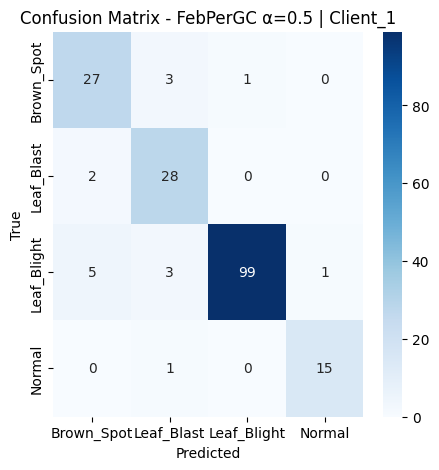

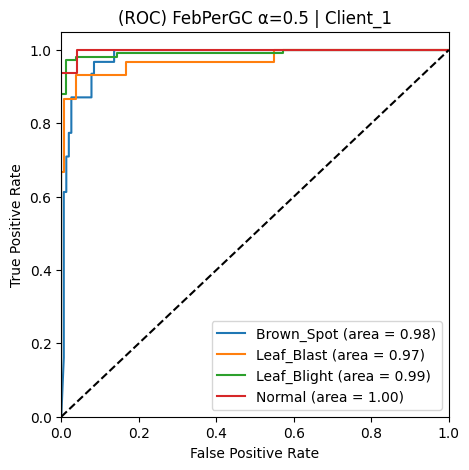

Number of test images: 185
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step
Total prediction time for 185 images: 18.82 seconds
Execution time per image: 0.1017 seconds
Client: Client_2
  Test counts: {'Brown_Spot': 5, 'Leaf_Blast': 25, 'Leaf_Blight': 30, 'Normal': 121}
  Total test images: 181
--------------------
Found 181 images belonging to 4 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.9724 - loss: 0.1188
Test Loss: 11.88322976231575
Test Accuracy: 97.23756909370422
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        55.56  100.00     71.43     5.00
Leaf_Blast        96.00   96.00     96.00    25.00
Leaf_Blight      100.00   96.67     98.31    30.00
Normal           100.00   97.52     98.74   121.00
accuracy          97.24   97.24     97.24     0.97
macro avg         87.89   97.55     91.12   181.00
weighted avg      98.22   97.24     97.54   181.00


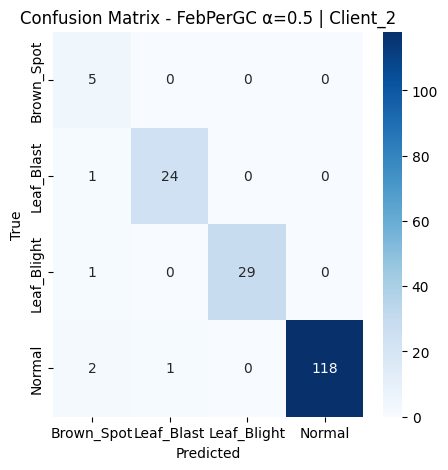

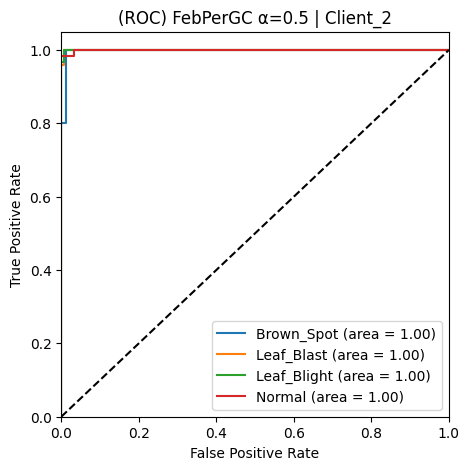

Number of test images: 181
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Total prediction time for 181 images: 13.05 seconds
Execution time per image: 0.0721 seconds
Client: Client_3
  Test counts: {'Brown_Spot': 34, 'Leaf_Blast': 9, 'Leaf_Blight': 22, 'Normal': 32}
  Total test images: 97
--------------------
Found 97 images belonging to 4 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 34s 10s/step - accuracy: 0.9897 - loss: 0.1340
Test Loss: 13.401338458061218
Test Accuracy: 98.96907210350037
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot       100.00   97.06     98.51    34.00
Leaf_Blast        90.00  100.00     94.74     9.00
Leaf_Blight      100.00  100.00    100.00    22.00
Normal           100.00  100.00    100.00    32.00
accuracy          98.97   98.97     98.97     0.99
macro avg         97.50   99.26     98.31    97.00
weighted avg      99.07   98.97     98.99    97.00


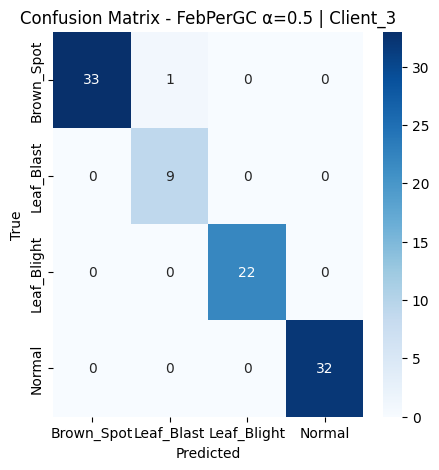

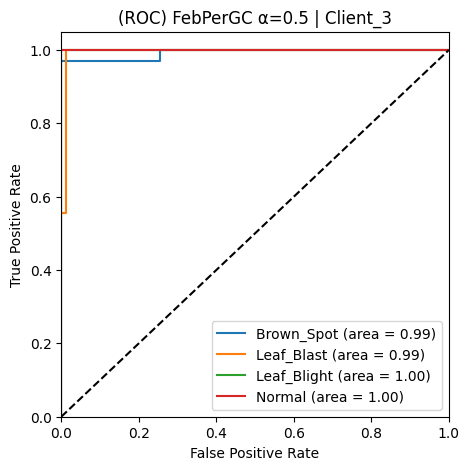

Number of test images: 97
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Total prediction time for 97 images: 8.60 seconds
Execution time per image: 0.0887 seconds
Client: Client_4
  Test counts: {'Brown_Spot': 139, 'Leaf_Blast': 41, 'Leaf_Blight': 5, 'Normal': 10}
  Total test images: 195
--------------------
Found 195 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 10s/step - accuracy: 0.9333 - loss: 0.2485
Test Loss: 24.850665032863617
Test Accuracy: 93.33333373069763
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        99.22   92.09     95.52   139.00
Leaf_Blast        86.67   95.12     90.70    41.00
Leaf_Blight       50.00  100.00     66.67     5.00
Normal            90.91  100.00     95.24    10.00
accuracy          93.33   93.33     93.33     0.93
macro avg         81.70   96.80     87.03   195.00
weighted avg      94.90   93.33     93.75   195.00


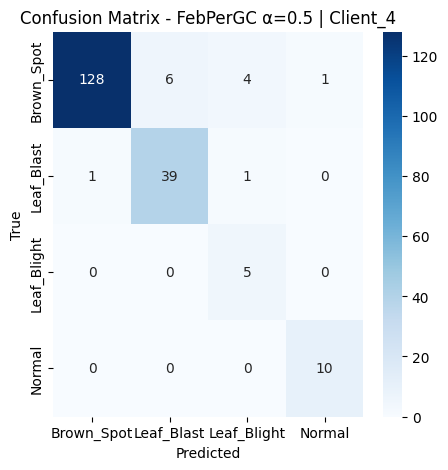

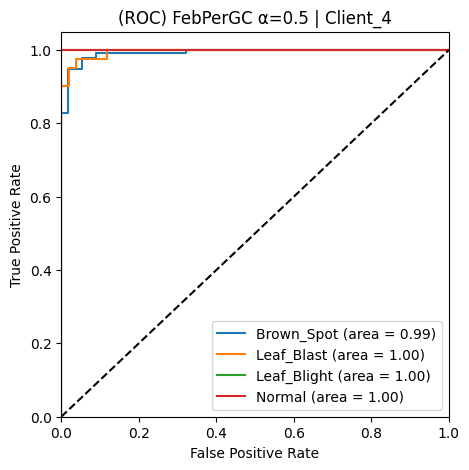

Number of test images: 195
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Total prediction time for 195 images: 10.77 seconds
Execution time per image: 0.0552 seconds
Client: Client_5
  Test counts: {'Brown_Spot': 15, 'Leaf_Blast': 58, 'Leaf_Blight': 39, 'Normal': 77}
  Total test images: 189
--------------------
Found 189 images belonging to 4 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 121s 24s/step - accuracy: 0.9524 - loss: 0.2855
Test Loss: 28.554731607437134
Test Accuracy: 95.23809552192688
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        77.78   93.33     84.85    15.00
Leaf_Blast        96.43   93.10     94.74    58.00
Leaf_Blight       94.87   94.87     94.87    39.00
Normal            98.68   97.40     98.04    77.00
accuracy          95.24   95.24     95.24     0.95
macro avg         91.94   94.68     93.12   189.00
weighted avg      95.55   95.24     95.33   189.00


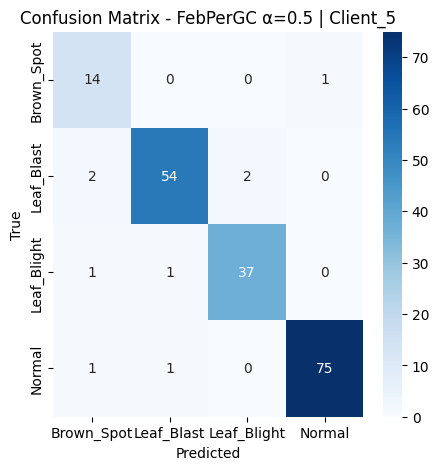

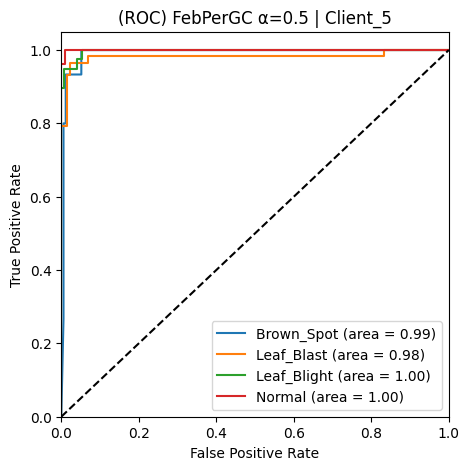

Number of test images: 189
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
Total prediction time for 189 images: 14.01 seconds
Execution time per image: 0.0741 seconds
Client: Client_6
  Test counts: {'Brown_Spot': 9, 'Leaf_Blast': 79, 'Leaf_Blight': 39, 'Normal': 19}
  Total test images: 146
--------------------
Found 146 images belonging to 4 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 80s 19s/step - accuracy: 0.9315 - loss: 0.2466
Test Loss: 24.66237097978592
Test Accuracy: 93.1506872177124
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step

Classification Report (in %):
              precision  recall  f1-score  support
Brown_Spot        57.14   88.89     69.57     9.00
Leaf_Blast        97.26   89.87     93.42    79.00
Leaf_Blight       95.12  100.00     97.50    39.00
Normal           100.00   94.74     97.30    19.00
accuracy          93.15   93.15     93.15     0.93
macro avg         87.38   93.37     89.45   146.00
weighted avg      94.57   93.15     93.54   146.00


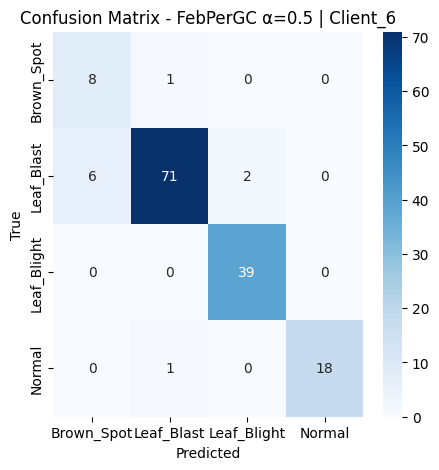

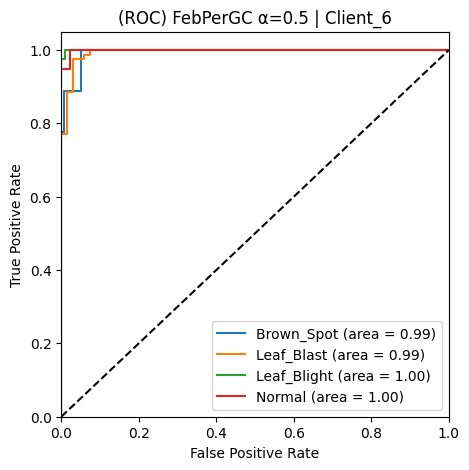

Number of test images: 146
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Total prediction time for 146 images: 21.25 seconds
Execution time per image: 0.1455 seconds


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
# --- Re-initialize fl_model with the original unquantized version ---
# Load the original unquantized model from the best model path
#model_dir = f'/content/drive/MyDrive/FL/model/{pass_name}'
#best_model_path = os.path.join(model_dir, "FL_final_global_model.keras")

# 32 - 89.05
round = 23
best_model_path = f"/content/drive/MyDrive/FL/model/FL_April_13th/round_{round}/global_model_round_{round}.keras"
print("Test by model:", best_model_path)
print("Test by model:", best_model_path)
if os.path.exists(best_model_path):
    try:
        print(f"Loading original initial global model from {best_model_path}...")
        fl_model = tf.keras.models.load_model(
            best_model_path,
            custom_objects=custom_objects
        )
        print("Original model loaded successfully for FL rounds.")

    except Exception as e:
        print(f"Error loading the original model for FL rounds: {e}")
        fl_model = None # Ensure fl_model is None if loading fails

else:
    print(f"Error: best_model_path does not exist at {best_model_path}. Cannot load the original model for FL rounds.")
    fl_model = None # Ensure fl_model is None if path is invalid

# Ensure fl_model is compiled before starting FL rounds
if fl_model:
     print("Compiling initial global model for FL rounds...")
     fl_model.compile(optimizer='adam',
                                  loss='categorical_crossentropy',
                                  metrics=['accuracy'])
     print("Model compiled for FL rounds.")
else:
    print("Initial global model not loaded successfully. Cannot start FL rounds.")

#-------------------------------------------------------------------------------

for client_name, info in clients_info.items():
    client_path = info["path"]
    client_classes = info["classes"]
    print(f"Client: {client_name}")
    test_dir = os.path.join(client_path, 'test')
    test_counts = count_images_by_class(test_dir, client_classes)
    print("  Test counts:", test_counts)
    print("  Total test images:", sum(test_counts.values()))
    print("-" * 20)
    title="FebPerGC α=0.5 | "+client_name
    #---------------------------------------------------------------------------
    valid_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = valid_datagen.flow_from_directory(
        test_dir,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )
    # Đánh giá mô hình
    loss, accuracy = fl_model.evaluate(test_generator)
    print("Test Loss:", loss*100)
    print("Test Accuracy:", accuracy*100)

    # Dự đoán
    y_pred = fl_model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_generator.classes

    # Lấy tên lớp
    global_classes = ["Brown_Spot", "Leaf_Blast", "Leaf_Blight", "Normal"]
    class_names = global_classes
    num_classes = len(class_names)
    # Classification report dưới dạng phần trăm
    report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df[['precision', 'recall', 'f1-score']] *= 100  # Nhân hệ số 10 để chuyển sang phần trăm

    # Làm tròn và in kết quả
    print("\nClassification Report (in %):")
    print(report_df.round(2))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - ' + title)
    plt.show()

    y_true_binarized = label_binarize(y_true, classes=np.arange(num_classes))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(5, 5))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('(ROC) '+title)
    plt.legend(loc="lower right")
    plt.show()



    # Load the final global model
    """try:
        # Assuming custom_objects are defined in a previous cell
        loaded_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
        print(f"Model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        loaded_model = None"""

    if fl_model:
        # Get the number of images in the test set
        num_test_images = test_generator.samples
        print(f"Number of test images: {num_test_images}")

        # Measure the prediction time
        start_time = time.time()
        fl_model.predict(test_generator)
        end_time = time.time()

        total_prediction_time = end_time - start_time
        print(f"Total prediction time for {num_test_images} images: {total_prediction_time:.2f} seconds")

        # Calculate execution time per image
        if num_test_images > 0:
            execution_time_per_image = total_prediction_time / num_test_images
            print(f"Execution time per image: {execution_time_per_image:.4f} seconds")
        else:
            print("No test images found to calculate execution time per image.")
    else:
        print("Could not load the model. Cannot calculate execution time.")


    #display(report_df.round(2))


In [ ]:
print()